# Membandingkan Kinerja Sensor Cyclic Voltammetry: LC (LecSens) vs PS (EmStat4)
## Deteksi Logam Berat Cadmium (Cd²⁺) — Range 2–1000 ppm

**Objektif:** Pemodelan dan evaluasi akurasi sensor berdasarkan data Cyclic Voltammetry, membandingkan sensor buatan sendiri (LC/LecSens) dengan sensor komersial (PS/EmStat4).

**Pipeline:**
1. Data Loading & Eksplorasi
2. Preprocessing: Baseline Correction + Savitzky-Golay Smoothing
3. Feature Extraction: Peak Current (Ip), Peak Potential (Ep), Area, dsb.
4. Dataset Assembly & EDA
5. Pemodelan: Linear, Polynomial, SVR, Random Forest, XGBoost, LightGBM
6. Evaluasi: 5-Fold CV dengan R², RMSE, MAE, MAPE
7. Perbandingan LC vs PS

---
## 1. Import Library & Konfigurasi

In [21]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.integrate import trapezoid

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'lines.linewidth': 1.8,
    'axes.grid': True,
    'grid.alpha': 0.4
})

# ==============================================================================
# KONFIGURASI PATH DATASET
# ==============================================================================
BASE_DIR   = Path(r'c:\Users\Hikar\Documents\Kuliah\Bahan Belajar Kuliah Semester 4\AI\UTS Kelas AI A')
LC_DIR     = BASE_DIR / 'Alat Sensor LC'
PS_DIR     = BASE_DIR / 'Alat Sensor PS'
OUTPUT_DIR = BASE_DIR / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Konsentrasi Cadmium (PPM) — 15 level (tidak termasuk KCL/0ppm, ditangani terpisah)
PPM_LEVELS = [2, 4, 6, 8, 10, 20, 40, 60, 80, 100, 200, 400, 600, 800, 1000]

# Scan yang digunakan untuk analisis (scan ke-3 s/d ke-10 = indeks 2–9)
STABLE_SCANS = list(range(2, 10))

# Window tegangan untuk deteksi peak — per sensor (V)
# LC (LecSens): stripping peak Cd²⁺ ≈ -0.52V, window sempit hindari spurious peak
PEAK_V_MIN_LC, PEAK_V_MAX_LC = -0.62, -0.43
# PS (EmStat4): peak bergeser dari -0.50V (rendah) s/d -0.70V (tinggi), window lebih lebar
PEAK_V_MIN_PS, PEAK_V_MAX_PS = -0.80, -0.43

# Alias legacy (backward-compat)
PEAK_V_MIN, PEAK_V_MAX = PEAK_V_MIN_PS, PEAK_V_MAX_PS

print('Konfigurasi berhasil dimuat.')
print(f'Output disimpan ke: {OUTPUT_DIR}')
print(f'LC  peak window: [{PEAK_V_MIN_LC}, {PEAK_V_MAX_LC}] V')
print(f'PS  peak window: [{PEAK_V_MIN_PS}, {PEAK_V_MAX_PS}] V')


Konfigurasi berhasil dimuat.
Output disimpan ke: c:\Users\Hikar\Documents\Kuliah\Bahan Belajar Kuliah Semester 4\AI\UTS Kelas AI A\output
LC  peak window: [-0.62, -0.43] V
PS  peak window: [-0.8, -0.43] V


---
## 2. Fungsi-Fungsi Preprocessing & Feature Extraction

In [22]:
def load_cv_file(filepath, sensor_type='LC'):
    """
    Membaca satu file xlsx hasil ekspor CV.
    Mengembalikan dict {scan_idx: {'V': array, 'I': array}}
    untuk scan 1–10.
    """
    try:
        if sensor_type == 'LC':
            df = pd.read_excel(filepath, header=[0, 1], sheet_name='Data CV')
        else:
            df = pd.read_excel(filepath, header=[0, 1], sheet_name=0)
    except Exception:
        df = pd.read_excel(filepath, header=[0, 1], sheet_name=0)

    if isinstance(df, dict):
        df = list(df.values())[0]

    scans = {}
    n_scans = df.shape[1] // 2
    for s in range(n_scans):
        v = df.iloc[:, s * 2].dropna().values.astype(float)
        i = df.iloc[:, s * 2 + 1].dropna().values.astype(float)
        if len(v) > 10:
            scans[s] = {'V': v, 'I': i}
    return scans


def get_anodic_sweep(v, i):
    """
    Mengekstrak HANYA bagian anodic (stripping) sweep dari satu scan CV.

    Logika adaptif:
    - LC (LecSens): scan DIMULAI dengan sweep anodic (V meningkat dari -1.1 ke -0.5)
      kemudian diikuti sweep katodik. Anodic = dari awal hingga V_local_max pertama.
    - PS (EmStat4): scan DIMULAI dengan sweep katodik (V turun dari -0.5 ke -1.4)
      kemudian diikuti sweep anodic. Anodic = dari V_min global hingga akhir scan.

    Deteksi otomatis berdasarkan arah sweep awal.
    """
    if len(v) < 5:
        return v, i

    # Cek arah sweep pertama (dV pada 10 poin pertama)
    initial_dv = np.diff(v[:min(10, len(v))])
    starts_anodic = np.mean(initial_dv) > 0   # True = LC, False = PS

    if starts_anodic:
        # LC: anodic sweep adalah bagian AWAL scan
        # Cari local V_max pertama (titik balik dari anodic ke cathodic)
        dv = np.diff(v)
        # Cari di mana V mulai turun (cathodic turn)
        first_cathodic = np.where(dv < 0)[0]
        if len(first_cathodic) == 0:
            return v, i  # Seluruh scan adalah anodic
        end_idx = first_cathodic[0]
        # Tolerance: abaikan noise di awal (max 5 titik)
        # Cari cathodic turn yang terjadi setelah minimal 20% data
        min_anodic_len = max(5, len(v) // 5)
        real_turn = [idx for idx in first_cathodic if idx >= min_anodic_len]
        if real_turn:
            end_idx = real_turn[0]
        return v[:end_idx + 1], i[:end_idx + 1]
    else:
        # PS: anodic sweep adalah bagian AKHIR scan (setelah V_min global)
        turn_idx = int(np.argmin(v))
        return v[turn_idx:], i[turn_idx:]


def extract_peak_features(v_anodic, i_anodic, v_min=-0.62, v_max=-0.43, smooth=True):
    """
    Mengekstrak fitur peak dari anodic sweep.

    - Ip    : net peak current (Ip_raw dikurangi background 5th-percentile)
    - Ep    : peak potential
    - Area  : integral muatan faradaic (area di atas baseline)
    - Ip_raw: raw peak current (tanpa koreksi baseline)

    Window v_min/v_max HARUS disesuaikan per sensor:
    - LC: v_min=PEAK_V_MIN_LC (-0.62), v_max=PEAK_V_MAX_LC (-0.43)
    - PS: v_min=PEAK_V_MIN_PS (-0.80), v_max=PEAK_V_MAX_PS (-0.43)

    Baseline correction: 5th-percentile dari arus dalam window digunakan sebagai
    background. Lebih robust dibanding endpoint-averaging karena endpoint bisa
    jatuh tepat di posisi peak sehingga Ip ≈ 0.
    """
    # Filter ke window tegangan peak
    mask = (v_anodic >= v_min) & (v_anodic <= v_max)
    if mask.sum() < 5:
        return None

    vw = v_anodic[mask]
    iw = i_anodic[mask]

    # Smoothing Savitzky-Golay
    if smooth and len(iw) >= 7:
        wl = min(9, len(iw) if len(iw) % 2 == 1 else len(iw) - 1)
        if wl < 5:
            wl = 5
        iw = savgol_filter(iw, window_length=wl, polyorder=3)

    # Raw peak (sebelum baseline correction)
    raw_peak_idx = np.argmax(iw)
    Ip_raw = float(iw[raw_peak_idx])
    Ep_raw = float(vw[raw_peak_idx])

    # Baseline correction: 5th-percentile sebagai background
    background = float(np.percentile(iw, 5))
    Ip = Ip_raw - background

    # Area integral (trapezoidal) di atas baseline — hanya nilai positif
    sort_idx = np.argsort(vw)
    vw_s = vw[sort_idx]
    iw_s = iw[sort_idx]
    iw_corrected = np.clip(iw_s - background, 0, None)
    area = float(trapezoid(iw_corrected, vw_s))

    return {
        'Ip'    : Ip,
        'Ep'    : Ep_raw,
        'Area'  : area,
        'Ip_raw': Ip_raw
    }


def process_single_file(filepath, sensor_type='LC', stable_scans=STABLE_SCANS):
    """
    Memproses satu file xlsx:
    1. Membaca semua scan
    2. Menggunakan scan stabil (scan ke-3 s/d ke-10)
    3. Ekstrak anodic sweep setiap scan
    4. Ekstrak fitur peak dengan window spesifik per sensor
    5. Rata-rata antar scan stabil

    Return: dict {Ip_mean, Ip_std, Ep_mean, Area_mean, Ip_raw_mean, n_valid}
    """
    scans = load_cv_file(filepath, sensor_type)

    # Pilih window peak sesuai sensor
    if sensor_type == 'LC':
        v_min_pk, v_max_pk = PEAK_V_MIN_LC, PEAK_V_MAX_LC
    else:
        v_min_pk, v_max_pk = PEAK_V_MIN_PS, PEAK_V_MAX_PS

    results = []
    for s_idx in stable_scans:
        if s_idx not in scans:
            continue
        v_full = scans[s_idx]['V']
        i_full = scans[s_idx]['I']

        v_anodic, i_anodic = get_anodic_sweep(v_full, i_full)
        if len(v_anodic) < 10:
            continue

        feats = extract_peak_features(v_anodic, i_anodic, v_min=v_min_pk, v_max=v_max_pk)
        if feats is not None:
            results.append(feats)

    if not results:
        return None

    return {
        'Ip_mean'    : float(np.mean([r['Ip']     for r in results])),
        'Ip_std'     : float(np.std( [r['Ip']     for r in results])),
        'Ip_raw_mean': float(np.mean([r['Ip_raw'] for r in results])),
        'Ep_mean'    : float(np.mean([r['Ep']     for r in results])),
        'Area_mean'  : float(np.mean([r['Area']   for r in results])),
        'n_valid'    : len(results)
    }


print('Fungsi preprocessing & feature extraction berhasil didefinisikan.')
print(f'  LC  peak window : [{PEAK_V_MIN_LC}, {PEAK_V_MAX_LC}] V  (sempit, hindari spurious peak)')
print(f'  PS  peak window : [{PEAK_V_MIN_PS}, {PEAK_V_MAX_PS}] V  (lebar, akomodasi shift peak)')
print('  Baseline method : 5th-percentile correction')


Fungsi preprocessing & feature extraction berhasil didefinisikan.
  LC  peak window : [-0.62, -0.43] V  (sempit, hindari spurious peak)
  PS  peak window : [-0.8, -0.43] V  (lebar, akomodasi shift peak)
  Baseline method : 5th-percentile correction


---
## 3. Data Loading — Membuat Dataset LC & PS

In [23]:
def build_dataset(sensor_dir, sensor_type, ppm_levels=PPM_LEVELS, include_kcl=True):
    """
    Memuat semua file dari semua folder PPM dan KCL, lalu membuat DataFrame.
    Setiap baris = satu file pengukuran (1 replicate).

    KCL (0 ppm Cd²⁺) dimasukkan sebagai titik baseline referensi (ppm=0)
    jika include_kcl=True dan folder KCL/ ada.
    log_ppm untuk KCL diset NaN karena log10(0) tidak terdefinisi.
    """
    records = []
    sensor_dir = Path(sensor_dir)

    # ── Load KCL (ppm=0) — background elektrolit tanpa Cd²⁺ ───────────────────
    if include_kcl:
        kcl_folder = sensor_dir / 'KCL'
        if kcl_folder.exists():
            kcl_files = sorted(kcl_folder.glob('*.xlsx'))
            n_ok = 0
            for fpath in kcl_files:
                feats = process_single_file(fpath, sensor_type=sensor_type)
                if feats is not None:
                    feats['ppm']      = 0
                    feats['log_ppm']  = float('nan')   # log10(0) tidak terdefinisi
                    feats['filename'] = fpath.name
                    records.append(feats)
                    n_ok += 1
            print(f'  PPM     0 (KCL): {n_ok}/{len(kcl_files)} file berhasil diproses')
        else:
            print(f'  [INFO] Folder KCL tidak ditemukan: {kcl_folder}')

    # ── Load level konsentrasi Cd²⁺ ────────────────────────────────────────────
    for ppm in ppm_levels:
        folder = sensor_dir / str(ppm)
        if not folder.exists():
            print(f'  [WARNING] Folder tidak ditemukan: {folder}')
            continue

        xlsx_files = sorted(folder.glob('*.xlsx'))
        if not xlsx_files:
            print(f'  [WARNING] Tidak ada file xlsx di: {folder}')
            continue

        n_ok = 0
        for fpath in xlsx_files:
            feats = process_single_file(fpath, sensor_type=sensor_type)
            if feats is not None:
                feats['ppm']      = ppm
                feats['log_ppm']  = np.log10(ppm)
                feats['filename'] = fpath.name
                records.append(feats)
                n_ok += 1

        print(f'  PPM {ppm:>5}: {n_ok}/{len(xlsx_files)} file berhasil diproses')

    df = pd.DataFrame(records)
    df = df.sort_values('ppm').reset_index(drop=True)
    return df


print('=== Loading Dataset LC (LecSens) ===')
df_lc = build_dataset(LC_DIR, sensor_type='LC')
print(f'\nDataset LC: {df_lc.shape[0]} sampel, {df_lc.shape[1]} kolom')

print('\n=== Loading Dataset PS (EmStat4) ===')
df_ps = build_dataset(PS_DIR, sensor_type='PS')
print(f'\nDataset PS: {df_ps.shape[0]} sampel, {df_ps.shape[1]} kolom')


=== Loading Dataset LC (LecSens) ===
  PPM     0 (KCL): 50/50 file berhasil diproses
  PPM     2: 50/50 file berhasil diproses
  PPM     4: 50/50 file berhasil diproses
  PPM     6: 50/50 file berhasil diproses
  PPM     8: 50/50 file berhasil diproses
  PPM    10: 50/50 file berhasil diproses
  PPM    20: 50/50 file berhasil diproses
  PPM    40: 50/50 file berhasil diproses
  PPM    60: 50/50 file berhasil diproses
  PPM    80: 50/50 file berhasil diproses
  PPM   100: 50/50 file berhasil diproses
  PPM   200: 50/50 file berhasil diproses
  PPM   400: 50/50 file berhasil diproses
  PPM   600: 50/50 file berhasil diproses
  PPM   800: 50/50 file berhasil diproses
  PPM  1000: 50/50 file berhasil diproses

Dataset LC: 800 sampel, 9 kolom

=== Loading Dataset PS (EmStat4) ===
  PPM     0 (KCL): 50/50 file berhasil diproses
  PPM     2: 50/50 file berhasil diproses
  PPM     4: 50/50 file berhasil diproses
  PPM     6: 50/50 file berhasil diproses
  PPM     8: 50/50 file berhasil diprose

In [24]:
# Simpan dataset ke CSV
df_lc.to_csv(OUTPUT_DIR / 'dataset_LC.csv', index=False)
df_ps.to_csv(OUTPUT_DIR / 'dataset_PS.csv', index=False)

print('Dataset LC — 5 baris pertama:')
display(df_lc.head())
print('\nDataset PS — 5 baris pertama:')
display(df_ps.head())

print('\nStatistik deskriptif Dataset LC:')
display(df_lc.describe().round(4))

Dataset LC — 5 baris pertama:


,Ip_mean,Ip_std,Ip_raw_mean,Ep_mean,Area_mean,n_valid,ppm,log_ppm,filename
0,3.508892,0.879284,38.062257,-0.61750,0.183337,8,0,NaN,KCL_LECSENS_01.xlsx
1,3.369446,0.419036,34.757019,-0.51875,0.202267,8,0,NaN,KCL_LECSENS_010.xlsx
2,3.555563,0.307524,34.672928,-0.51875,0.217111,8,0,NaN,KCL_LECSENS_011.xlsx
3,3.664651,0.466183,34.720708,-0.52000,0.225405,8,0,NaN,KCL_LECSENS_012.xlsx
4,3.569033,0.480655,34.473528,-0.51875,0.234020,8,0,NaN,KCL_LECSENS_013.xlsx



Dataset PS — 5 baris pertama:


,Ip_mean,Ip_std,Ip_raw_mean,Ep_mean,Area_mean,n_valid,ppm,log_ppm,filename
0,27.155656,0.157960,39.724822,-0.608823,5.621993,8,0,NaN,KCL_EMSTAT_01.xlsx
1,24.296650,0.178452,37.141075,-0.633842,5.043835,8,0,NaN,KCL_EMSTAT_02.xlsx
2,23.866447,0.312140,37.929445,-0.546274,4.936161,8,0,NaN,KCL_EMSTAT_03.xlsx
3,16.634479,0.592020,31.840406,-0.630089,3.573602,8,0,NaN,KCL_EMSTAT_04.xlsx
4,16.349823,0.422338,31.431452,-0.508745,3.426293,8,0,NaN,KCL_EMSTAT_05.xlsx



Statistik deskriptif Dataset LC:


,Ip_mean,Ip_std,Ip_raw_mean,Ep_mean,Area_mean,n_valid,ppm,log_ppm
count,800.0000,800.0000,800.0000,800.0000,800.0000,800.0,800.0000,750.0000
mean,8.4305,0.7502,42.6378,-0.5415,0.5032,8.0,208.1250,1.7169
std,19.5386,0.9040,26.4863,0.0412,1.2247,0.0,309.3418,0.8536
min,0.7097,0.0863,20.1177,-0.6200,0.0431,8.0,0.0000,0.3010
25%,1.8545,0.3002,30.3243,-0.5750,0.1011,8.0,7.5000,0.9031
50%,2.8342,0.4505,33.8597,-0.5188,0.1563,8.0,50.0000,1.7782
75%,4.4351,0.6997,42.2681,-0.5112,0.2452,8.0,250.0000,2.6021
max,88.7696,7.1843,149.1625,-0.5000,5.6351,8.0,1000.0000,3.0000


---
## 4. Exploratory Data Analysis (EDA)

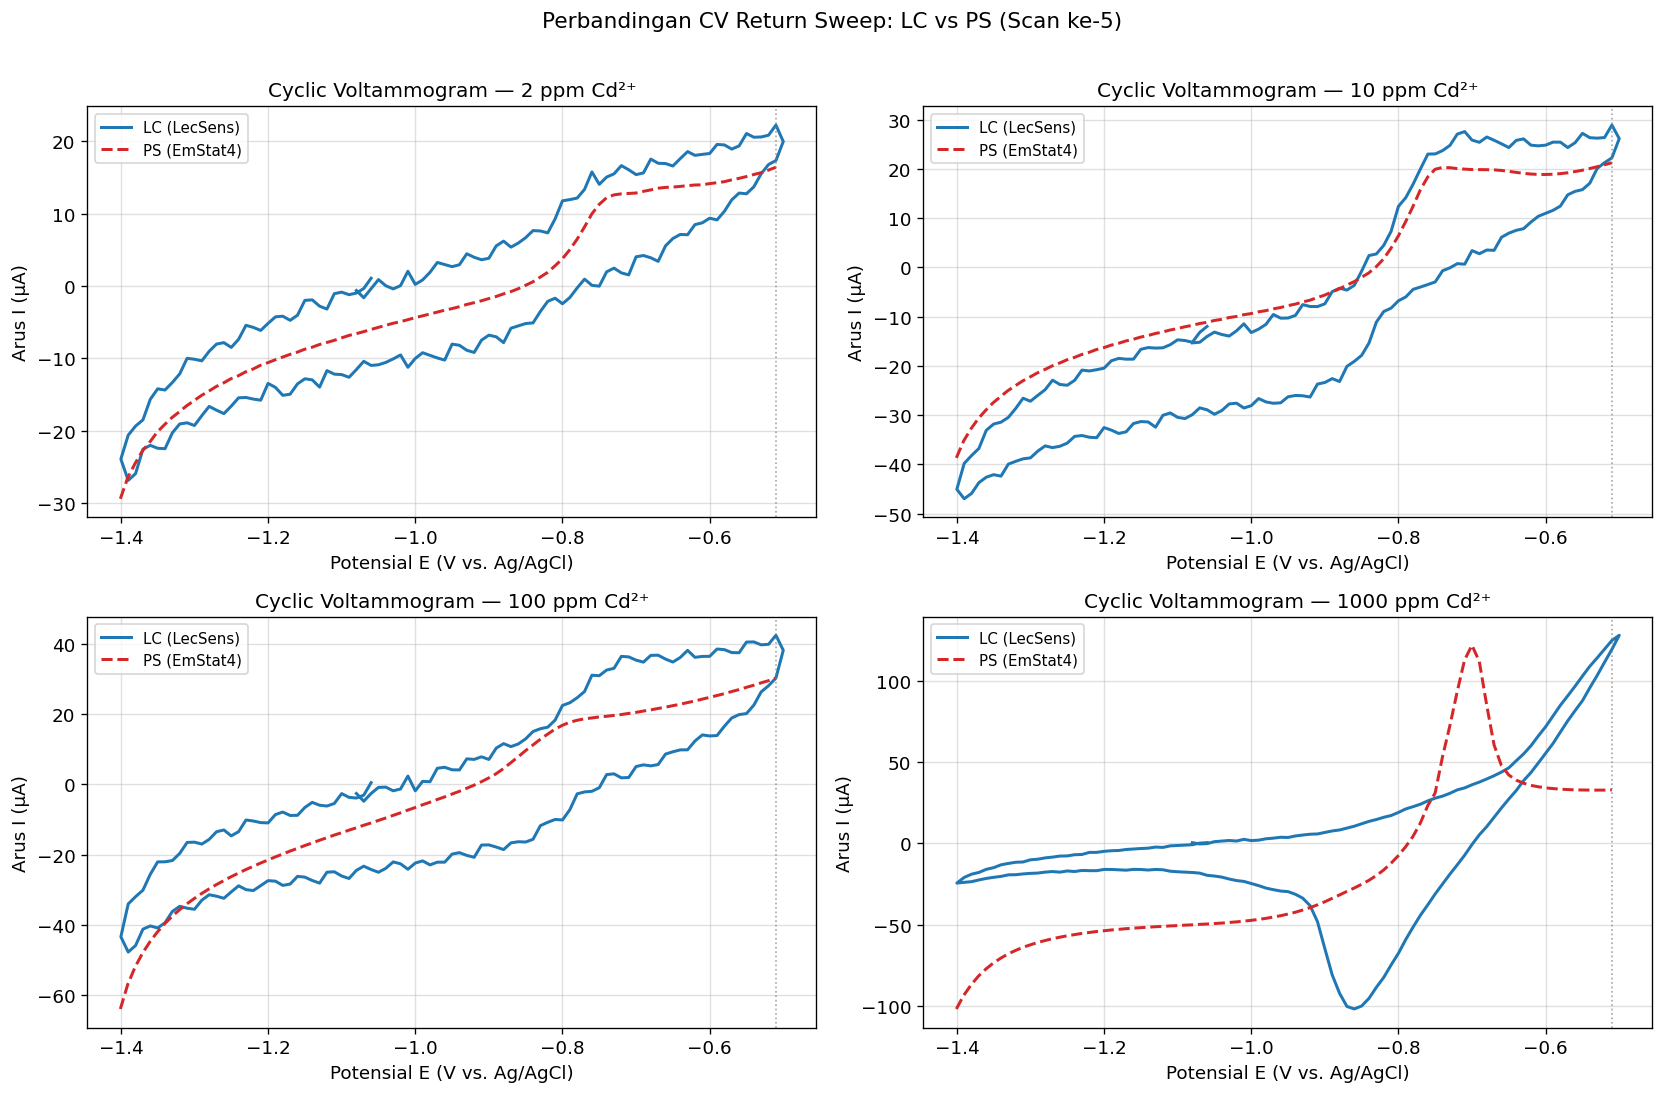

In [25]:
# ── 4.1 Contoh Voltammogram CV dari Beberapa Konsentrasi ──────────────────────
ppm_showcase = [2, 10, 100, 1000]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, ppm_val in zip(axes, ppm_showcase):
    # Load satu file LC
    lc_folder = LC_DIR / str(ppm_val)
    lc_files  = sorted(lc_folder.glob('*.xlsx'))
    scans_lc  = load_cv_file(lc_files[0], 'LC')
    
    # Load satu file PS
    ps_folder = PS_DIR / str(ppm_val)
    ps_files  = sorted(ps_folder.glob('*.xlsx'))
    scans_ps  = load_cv_file(ps_files[0], 'PS')
    
    # Plot return sweep scan 5 (indeks 4)
    for s_idx in [4]:  # scan ke-5 saja
        if s_idx in scans_lc:
            v, i = scans_lc[s_idx]['V'], scans_lc[s_idx]['I']
            v_r, i_r = get_return_sweep(v, i)
            ax.plot(v_r, i_r, color='#1f77b4', lw=1.8, label='LC (LecSens)')
        if s_idx in scans_ps:
            v, i = scans_ps[s_idx]['V'], scans_ps[s_idx]['I']
            v_r, i_r = get_return_sweep(v, i)
            ax.plot(v_r, i_r, color='#d62728', lw=1.8, linestyle='--', label='PS (EmStat4)')
    
    ax.axvline(x=-0.51, color='gray', lw=1, linestyle=':', alpha=0.7)
    ax.set_title(f'Cyclic Voltammogram — {ppm_val} ppm Cd²⁺')
    ax.set_xlabel('Potensial E (V vs. Ag/AgCl)')
    ax.set_ylabel('Arus I (µA)')
    ax.legend(fontsize=9)

plt.suptitle('Perbandingan CV Return Sweep: LC vs PS (Scan ke-5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig1_voltammogram_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

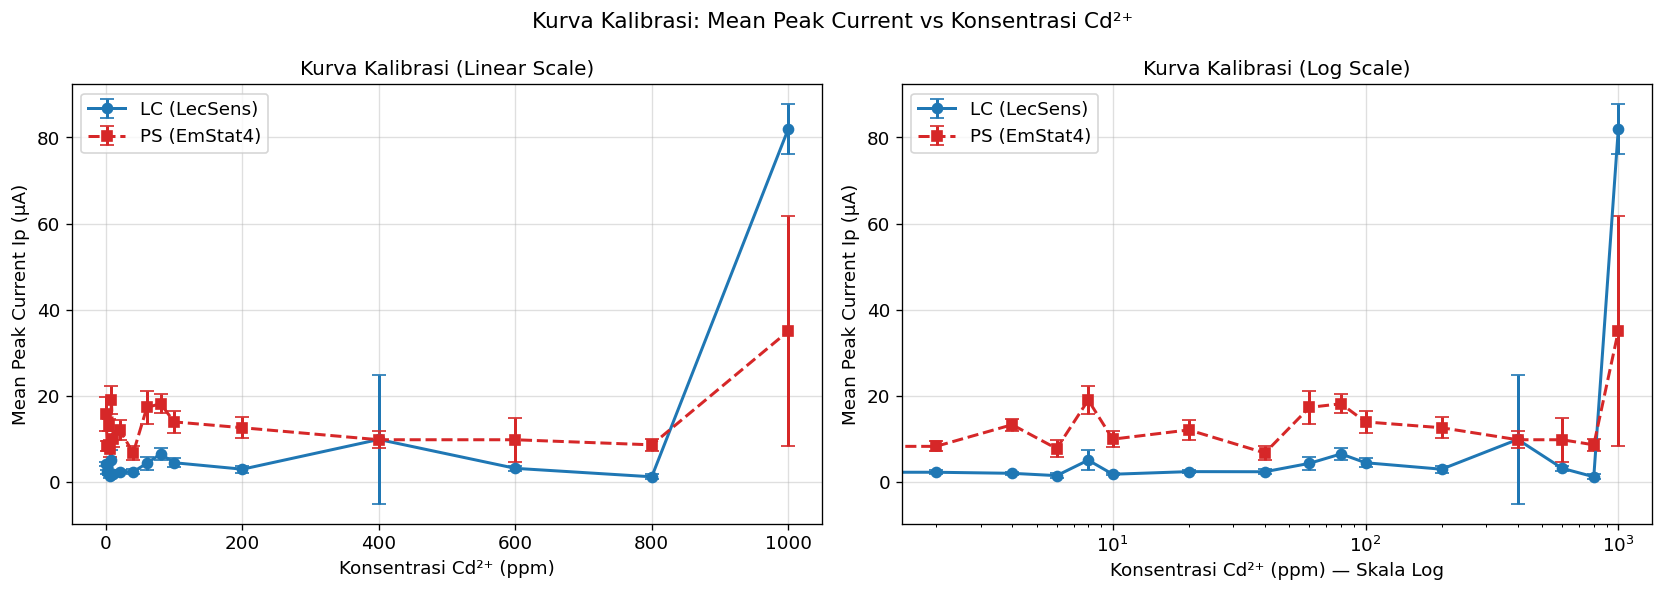

In [26]:
# ── 4.2 Kurva Kalibrasi — Mean Peak Current vs Konsentrasi ───────────────────
lc_stats = df_lc.groupby('ppm')['Ip_mean'].agg(['mean', 'std']).reset_index()
ps_stats = df_ps.groupby('ppm')['Ip_mean'].agg(['mean', 'std']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax = axes[0]
ax.errorbar(lc_stats['ppm'], lc_stats['mean'], yerr=lc_stats['std'],
            fmt='o-', color='#1f77b4', capsize=4, label='LC (LecSens)', ms=6)
ax.errorbar(ps_stats['ppm'], ps_stats['mean'], yerr=ps_stats['std'],
            fmt='s--', color='#d62728', capsize=4, label='PS (EmStat4)', ms=6)
ax.set_xlabel('Konsentrasi Cd²⁺ (ppm)')
ax.set_ylabel('Mean Peak Current Ip (µA)')
ax.set_title('Kurva Kalibrasi (Linear Scale)')
ax.legend()

# Log scale
ax = axes[1]
ax.errorbar(lc_stats['ppm'], lc_stats['mean'], yerr=lc_stats['std'],
            fmt='o-', color='#1f77b4', capsize=4, label='LC (LecSens)', ms=6)
ax.errorbar(ps_stats['ppm'], ps_stats['mean'], yerr=ps_stats['std'],
            fmt='s--', color='#d62728', capsize=4, label='PS (EmStat4)', ms=6)
ax.set_xscale('log')
ax.set_xlabel('Konsentrasi Cd²⁺ (ppm) — Skala Log')
ax.set_ylabel('Mean Peak Current Ip (µA)')
ax.set_title('Kurva Kalibrasi (Log Scale)')
ax.legend()

plt.suptitle('Kurva Kalibrasi: Mean Peak Current vs Konsentrasi Cd²⁺', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig2_calibration_curve.png', bbox_inches='tight', dpi=150)
plt.show()

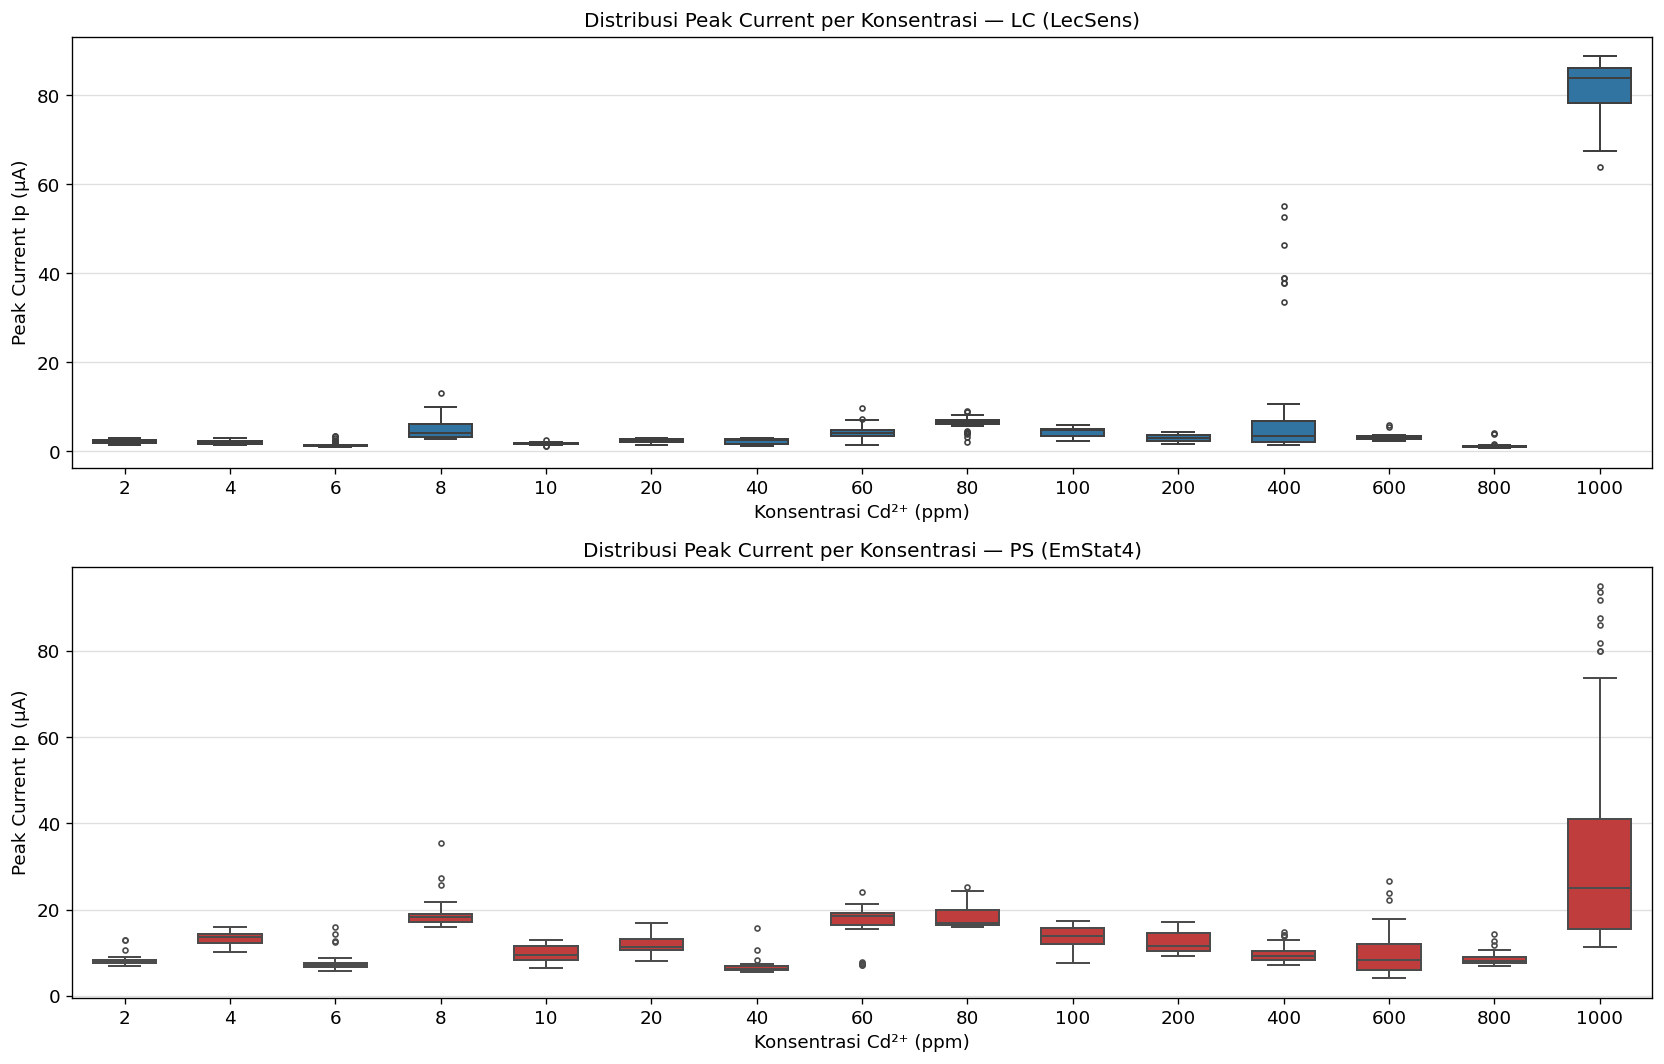

In [27]:
# ── 4.3 Distribusi Ip per PPM — Boxplot ──────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for ax, (df_plot, sensor_name, color) in zip(axes,
    [(df_lc, 'LC (LecSens)', '#1f77b4'), (df_ps, 'PS (EmStat4)', '#d62728')]):
    df_plot['ppm_str'] = df_plot['ppm'].astype(str)
    order = [str(p) for p in PPM_LEVELS if str(p) in df_plot['ppm_str'].values]
    sns.boxplot(data=df_plot, x='ppm_str', y='Ip_mean', order=order,
                color=color, ax=ax, width=0.6, linewidth=1.2, fliersize=3)
    ax.set_xlabel('Konsentrasi Cd²⁺ (ppm)')
    ax.set_ylabel('Peak Current Ip (µA)')
    ax.set_title(f'Distribusi Peak Current per Konsentrasi — {sensor_name}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig3_boxplot_ip_per_ppm.png', bbox_inches='tight', dpi=150)
plt.show()

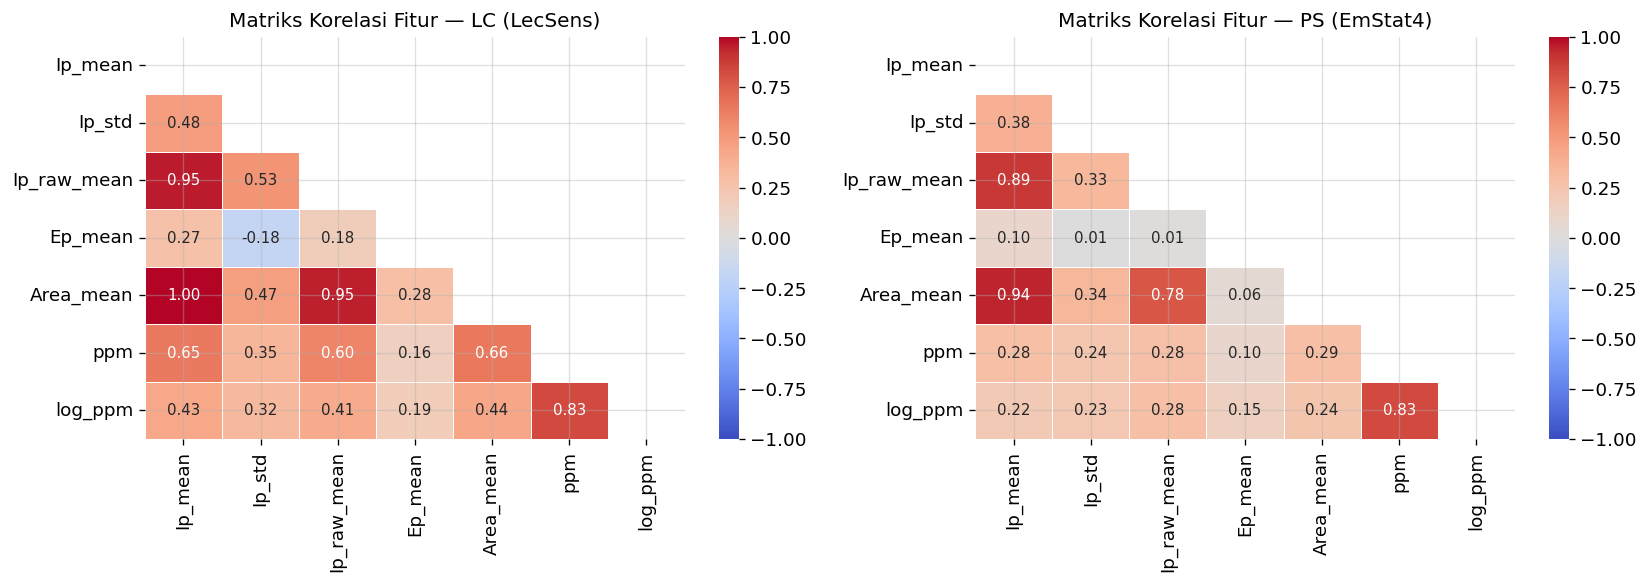

In [28]:
# ── 4.4 Korelasi Fitur ────────────────────────────────────────────────────────
feature_cols = ['Ip_mean', 'Ip_std', 'Ip_raw_mean', 'Ep_mean', 'Area_mean', 'ppm', 'log_ppm']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (df_c, title) in zip(axes, [(df_lc[feature_cols], 'LC (LecSens)'), (df_ps[feature_cols], 'PS (EmStat4)')]):
    corr = df_c.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                ax=ax, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9})
    ax.set_title(f'Matriks Korelasi Fitur — {title}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig4_correlation_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. Pemodelan Multi-Model

In [29]:
# ── 5.1 Persiapan Feature Matrix & Target ─────────────────────────────────────
# Fitur input: Ip_mean (utama), Ip_std, Ep_mean, Area_mean
# Target     : ppm (konsentrasi sebenarnya)

FEATURE_COLS = ['Ip_mean', 'Ip_std', 'Ep_mean', 'Area_mean']
TARGET_COL   = 'ppm'

X_lc = df_lc[FEATURE_COLS].values
y_lc = df_lc[TARGET_COL].values

X_ps = df_ps[FEATURE_COLS].values
y_ps = df_ps[TARGET_COL].values

print(f'Dataset LC: X={X_lc.shape}, y={y_lc.shape}')
print(f'Dataset PS: X={X_ps.shape}, y={y_ps.shape}')
print(f'Range ppm: {y_lc.min()} – {y_lc.max()}')

Dataset LC: X=(800, 4), y=(800,)
Dataset PS: X=(797, 4), y=(797,)
Range ppm: 0 – 1000


In [30]:
# ── 5.2 Definisi Model ────────────────────────────────────────────────────────
def make_models():
    """Mendefinisikan 7 model regresi dalam pipeline yang konsisten."""
    models = {
        'Linear Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('reg',    LinearRegression())
        ]),
        'Ridge Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('reg',    Ridge(alpha=1.0))
        ]),
        'Polynomial Reg (deg=3)': Pipeline([
            ('scaler', StandardScaler()),
            ('poly',   PolynomialFeatures(degree=3, include_bias=False)),
            ('reg',    Ridge(alpha=1.0))
        ]),
        'SVR (RBF)': Pipeline([
            ('scaler', StandardScaler()),
            ('reg',    SVR(kernel='rbf', C=500, gamma='scale', epsilon=10))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('reg',    RandomForestRegressor(
                n_estimators=300, max_depth=None, min_samples_leaf=2,
                random_state=42, n_jobs=-1
            ))
        ]),
        'XGBoost': Pipeline([
            ('scaler', StandardScaler()),
            ('reg',    xgb.XGBRegressor(
                n_estimators=300, max_depth=6, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                random_state=42, verbosity=0
            ))
        ]),
        'LightGBM': Pipeline([
            ('scaler', StandardScaler()),
            ('reg',    lgb.LGBMRegressor(
                n_estimators=300, max_depth=6, learning_rate=0.05,
                num_leaves=31, subsample=0.8, random_state=42,
                verbose=-1
            ))
        ])
    }
    return models


print('Model yang akan diuji:')
for name in make_models().keys():
    print(f'  • {name}')

Model yang akan diuji:
  • Linear Regression
  • Ridge Regression
  • Polynomial Reg (deg=3)
  • SVR (RBF)
  • Random Forest
  • XGBoost
  • LightGBM


In [31]:
# ── 5.3 Fungsi Evaluasi 5-Fold Cross-Validation ───────────────────────────────
def mape_score(y_true, y_pred):
    """Mean Absolute Percentage Error (%)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return 100 * np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def evaluate_models(X, y, n_splits=5, random_state=42):
    """
    Menjalankan 5-Fold CV untuk semua model.
    Mengembalikan DataFrame hasil metrik evaluasi.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    models = make_models()
    
    results = []
    for model_name, pipeline in models.items():
        r2_list, rmse_list, mae_list, mape_list = [], [], [], []
        
        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_test)
            
            r2_list.append(r2_score(y_test, y_pred))
            rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
            mae_list.append(mean_absolute_error(y_test, y_pred))
            mape_list.append(mape_score(y_test, y_pred))
        
        results.append({
            'Model'    : model_name,
            'R²'       : f'{np.mean(r2_list):.4f} ± {np.std(r2_list):.4f}',
            'R²_mean'  : np.mean(r2_list),
            'RMSE (ppm)': f'{np.mean(rmse_list):.2f} ± {np.std(rmse_list):.2f}',
            'RMSE_mean': np.mean(rmse_list),
            'MAE (ppm)': f'{np.mean(mae_list):.2f} ± {np.std(mae_list):.2f}',
            'MAE_mean' : np.mean(mae_list),
            'MAPE (%)'  : f'{np.mean(mape_list):.2f} ± {np.std(mape_list):.2f}',
            'MAPE_mean': np.mean(mape_list),
        })
    
    df_res = pd.DataFrame(results).sort_values('R²_mean', ascending=False).reset_index(drop=True)
    return df_res


print('Menjalankan 5-Fold CV untuk Dataset LC...')
results_lc = evaluate_models(X_lc, y_lc)
print('Selesai!\n')

print('Menjalankan 5-Fold CV untuk Dataset PS...')
results_ps = evaluate_models(X_ps, y_ps)
print('Selesai!')

Menjalankan 5-Fold CV untuk Dataset LC...
Selesai!

Menjalankan 5-Fold CV untuk Dataset PS...
Selesai!


---
## 6. Hasil Evaluasi

In [32]:
# ── 6.1 Tabel Hasil Evaluasi ──────────────────────────────────────────────────
display_cols = ['Model', 'R²', 'RMSE (ppm)', 'MAE (ppm)', 'MAPE (%)']

print('=' * 70)
print('HASIL EVALUASI 5-FOLD CV — DATASET LC (LecSens)')
print('=' * 70)
display(results_lc[display_cols])

print('\n' + '=' * 70)
print('HASIL EVALUASI 5-FOLD CV — DATASET PS (EmStat4)')
print('=' * 70)
display(results_ps[display_cols])

# Simpan ke CSV
results_lc.to_csv(OUTPUT_DIR / 'results_LC.csv', index=False)
results_ps.to_csv(OUTPUT_DIR / 'results_PS.csv', index=False)
print('\nHasil evaluasi tersimpan di output/')


HASIL EVALUASI 5-FOLD CV — DATASET LC (LecSens)


,Model,R²,RMSE (ppm),MAE (ppm),MAPE (%)
0,XGBoost,0.8232 ± 0.0289,127.85 ± 5.27,69.99 ± 3.32,520.08 ± 60.15
1,Random Forest,0.8200 ± 0.0402,128.69 ± 11.65,68.47 ± 3.31,501.46 ± 83.22
2,LightGBM,0.7958 ± 0.0631,135.79 ± 15.38,82.78 ± 8.53,653.72 ± 98.85
3,Polynomial Reg (deg=3),0.4874 ± 0.1294,216.46 ± 18.72,147.89 ± 9.81,1084.97 ± 194.52
4,Linear Regression,0.4309 ± 0.0942,229.61 ± 13.13,168.91 ± 7.10,1133.98 ± 171.20
5,Ridge Regression,0.4232 ± 0.0995,231.04 ± 12.99,171.33 ± 6.68,1143.38 ± 178.23
6,SVR (RBF),0.3635 ± 0.0982,243.29 ± 19.10,120.97 ± 14.40,248.51 ± 34.13



HASIL EVALUASI 5-FOLD CV — DATASET PS (EmStat4)


,Model,R²,RMSE (ppm),MAE (ppm),MAPE (%)
0,XGBoost,0.5794 ± 0.0225,199.54 ± 8.47,112.41 ± 6.25,666.33 ± 61.39
1,Random Forest,0.5571 ± 0.0631,204.19 ± 12.85,111.13 ± 9.37,593.84 ± 58.95
2,LightGBM,0.5265 ± 0.0478,211.40 ± 10.07,130.83 ± 8.35,810.40 ± 138.37
3,SVR (RBF),0.2641 ± 0.0632,264.34 ± 22.57,141.20 ± 14.15,408.36 ± 86.48
4,Ridge Regression,0.0784 ± 0.0331,295.67 ± 16.67,233.63 ± 9.51,1458.90 ± 269.12
5,Linear Regression,0.0782 ± 0.0332,295.71 ± 16.68,233.62 ± 9.51,1458.26 ± 268.90
6,Polynomial Reg (deg=3),-103.0639 ± 141.9488,2104.55 ± 2379.16,329.78 ± 200.04,1273.00 ± 291.47



Hasil evaluasi tersimpan di output/


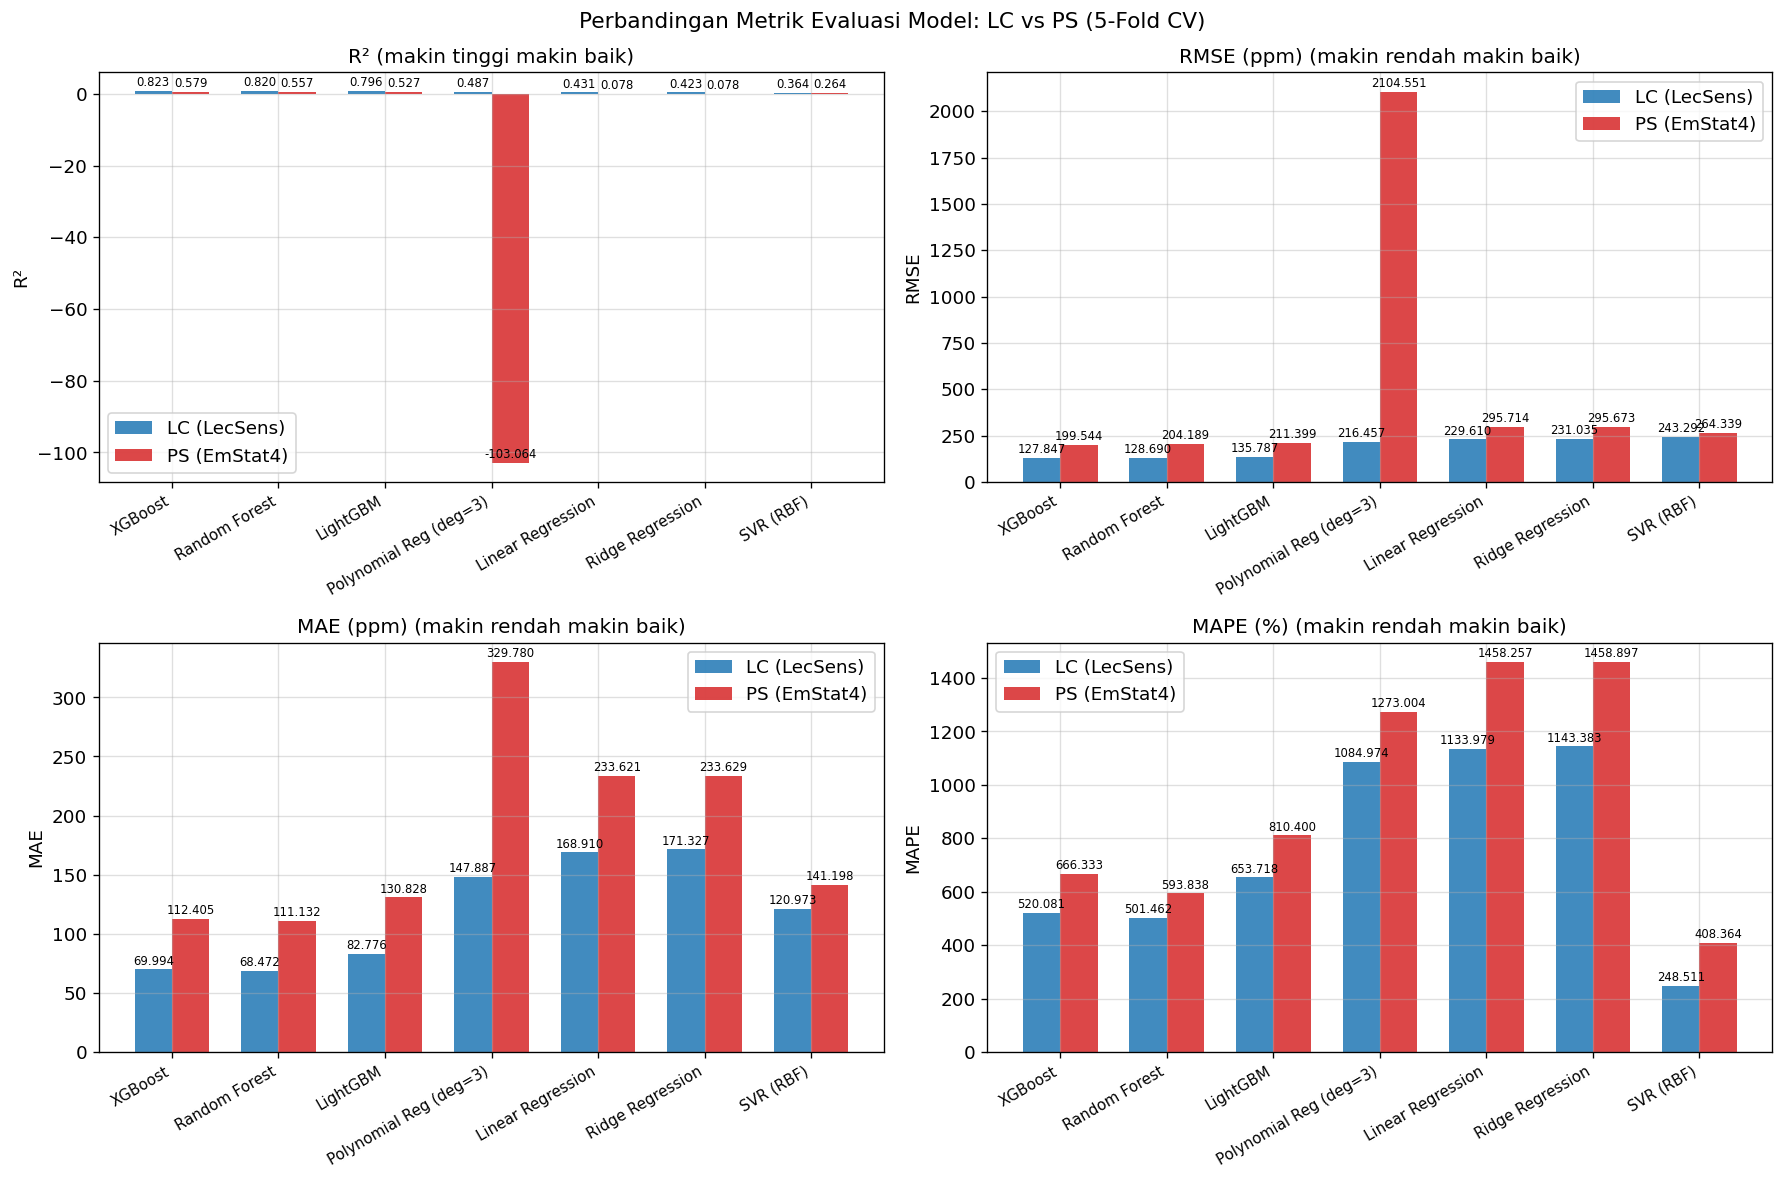

In [33]:
# ── 6.2 Visualisasi Perbandingan Metrik ──────────────────────────────────────
metrics_plot = ['R²_mean', 'RMSE_mean', 'MAE_mean', 'MAPE_mean']
metric_labels = ['R² (makin tinggi makin baik)',
                 'RMSE (ppm) (makin rendah makin baik)',
                 'MAE (ppm) (makin rendah makin baik)',
                 'MAPE (%) (makin rendah makin baik)']

model_names = results_lc['Model'].tolist()
x = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax, metric, label in zip(axes, metrics_plot, metric_labels):
    lc_vals = results_lc.set_index('Model').loc[model_names, metric].values
    ps_vals = results_ps.set_index('Model').loc[model_names, metric].values
    
    bars1 = ax.bar(x - width/2, lc_vals, width, label='LC (LecSens)', color='#1f77b4', alpha=0.85)
    bars2 = ax.bar(x + width/2, ps_vals, width, label='PS (EmStat4)', color='#d62728', alpha=0.85)
    
    ax.set_xticks(x)
    ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(label.split('(')[0].strip())
    ax.set_title(label)
    ax.legend()
    
    # Tambah nilai di atas bar
    for bar in bars1:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)
    for bar in bars2:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords='offset points', ha='center', fontsize=7)

plt.suptitle('Perbandingan Metrik Evaluasi Model: LC vs PS (5-Fold CV)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig5_model_comparison_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

Mengumpulkan data fold untuk boxplot R²...


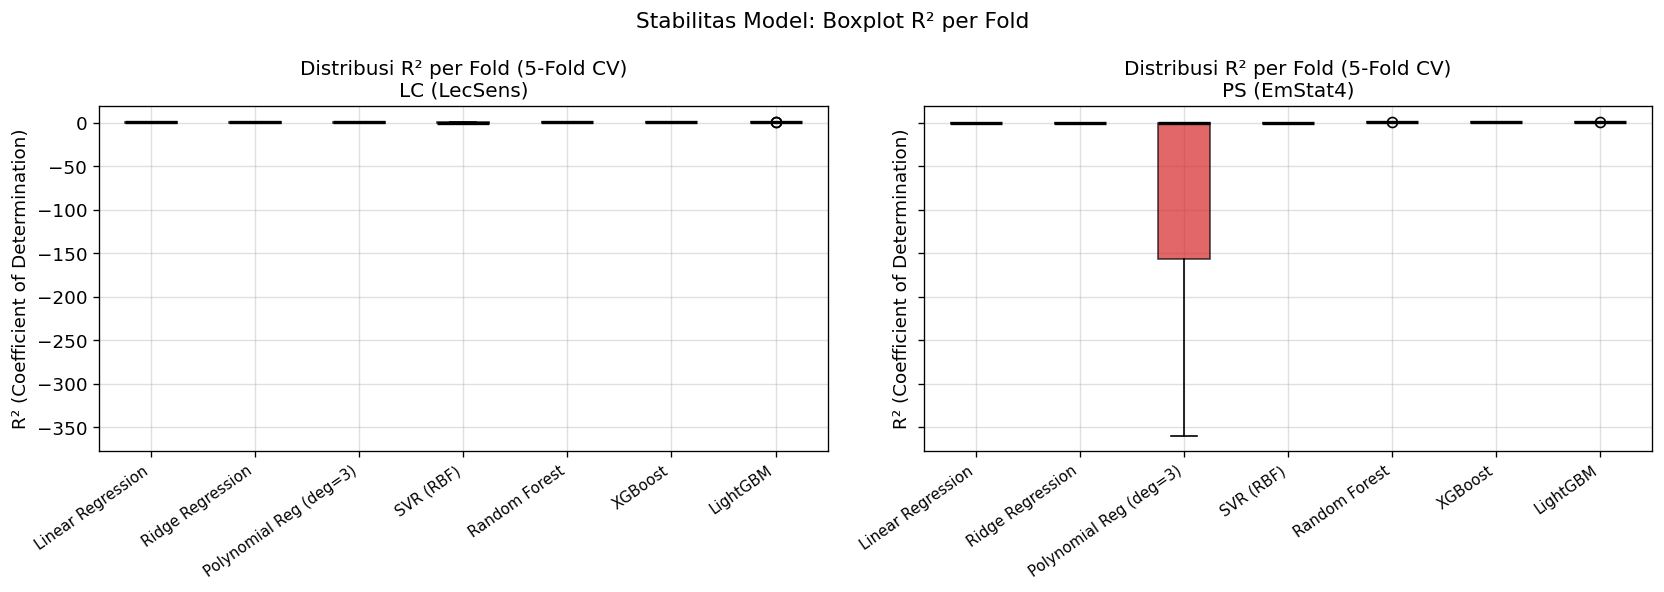

In [34]:
# ── 6.3 Boxplot R² dari setiap Fold per Model ─────────────────────────────────
def get_fold_metrics(X, y, n_splits=5, random_state=42):
    """Mengembalikan R² per fold untuk setiap model."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    models = make_models()
    fold_results = {name: [] for name in models}
    
    for model_name, pipeline in models.items():
        for train_idx, test_idx in kf.split(X):
            pipeline.fit(X[train_idx], y[train_idx])
            y_pred = pipeline.predict(X[test_idx])
            fold_results[model_name].append(r2_score(y[test_idx], y_pred))
    return fold_results

print('Mengumpulkan data fold untuk boxplot R²...')
fold_lc = get_fold_metrics(X_lc, y_lc)
fold_ps = get_fold_metrics(X_ps, y_ps)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, fold_data, sensor_name, color in zip(
        axes,
        [fold_lc, fold_ps],
        ['LC (LecSens)', 'PS (EmStat4)'],
        ['#1f77b4', '#d62728']):
    
    data   = list(fold_data.values())
    labels = list(fold_data.keys())
    bp = ax.boxplot(data, labels=labels, patch_artist=True, vert=True,
                    medianprops={'color': 'black', 'lw': 2})
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('R² (Coefficient of Determination)')
    ax.set_title(f'Distribusi R² per Fold (5-Fold CV)\n{sensor_name}')

plt.suptitle('Stabilitas Model: Boxplot R² per Fold', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig6_r2_boxplot_per_fold.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 7. Analisis Model Terbaik

Model terbaik LC: XGBoost
Model terbaik PS: XGBoost


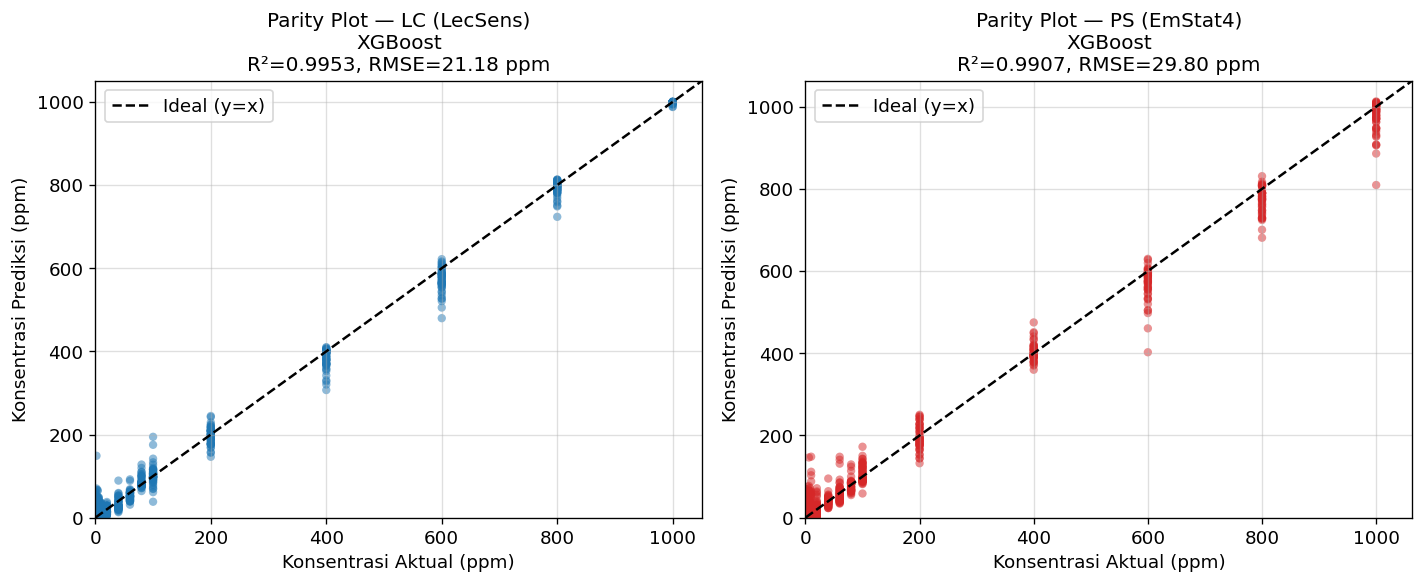

In [35]:
# ── 7.1 Train model terbaik pada full dataset → Parity Plot ───────────────────
best_lc_name = results_lc.iloc[0]['Model']
best_ps_name = results_ps.iloc[0]['Model']

print(f'Model terbaik LC: {best_lc_name}')
print(f'Model terbaik PS: {best_ps_name}')

# Ambil model terbaik dari factory
models_lc = make_models()
models_ps = make_models()

best_lc = models_lc[best_lc_name]
best_ps = models_ps[best_ps_name]

best_lc.fit(X_lc, y_lc)
best_ps.fit(X_ps, y_ps)

y_pred_lc = best_lc.predict(X_lc)
y_pred_ps = best_ps.predict(X_ps)

# Parity Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, sensor, color, model_name in zip(
        axes,
        [y_lc, y_ps],
        [y_pred_lc, y_pred_ps],
        ['LC (LecSens)', 'PS (EmStat4)'],
        ['#1f77b4', '#d62728'],
        [best_lc_name, best_ps_name]):
    
    ax.scatter(y_true, y_pred, c=color, alpha=0.5, s=25, edgecolors='none')
    lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
    ax.plot(lim, lim, 'k--', lw=1.5, label='Ideal (y=x)')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Konsentrasi Aktual (ppm)')
    ax.set_ylabel('Konsentrasi Prediksi (ppm)')
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    ax.set_title(f'Parity Plot — {sensor}\n{model_name}\nR²={r2:.4f}, RMSE={rmse:.2f} ppm')
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig7_parity_plot_best_model.png', bbox_inches='tight', dpi=150)
plt.show()

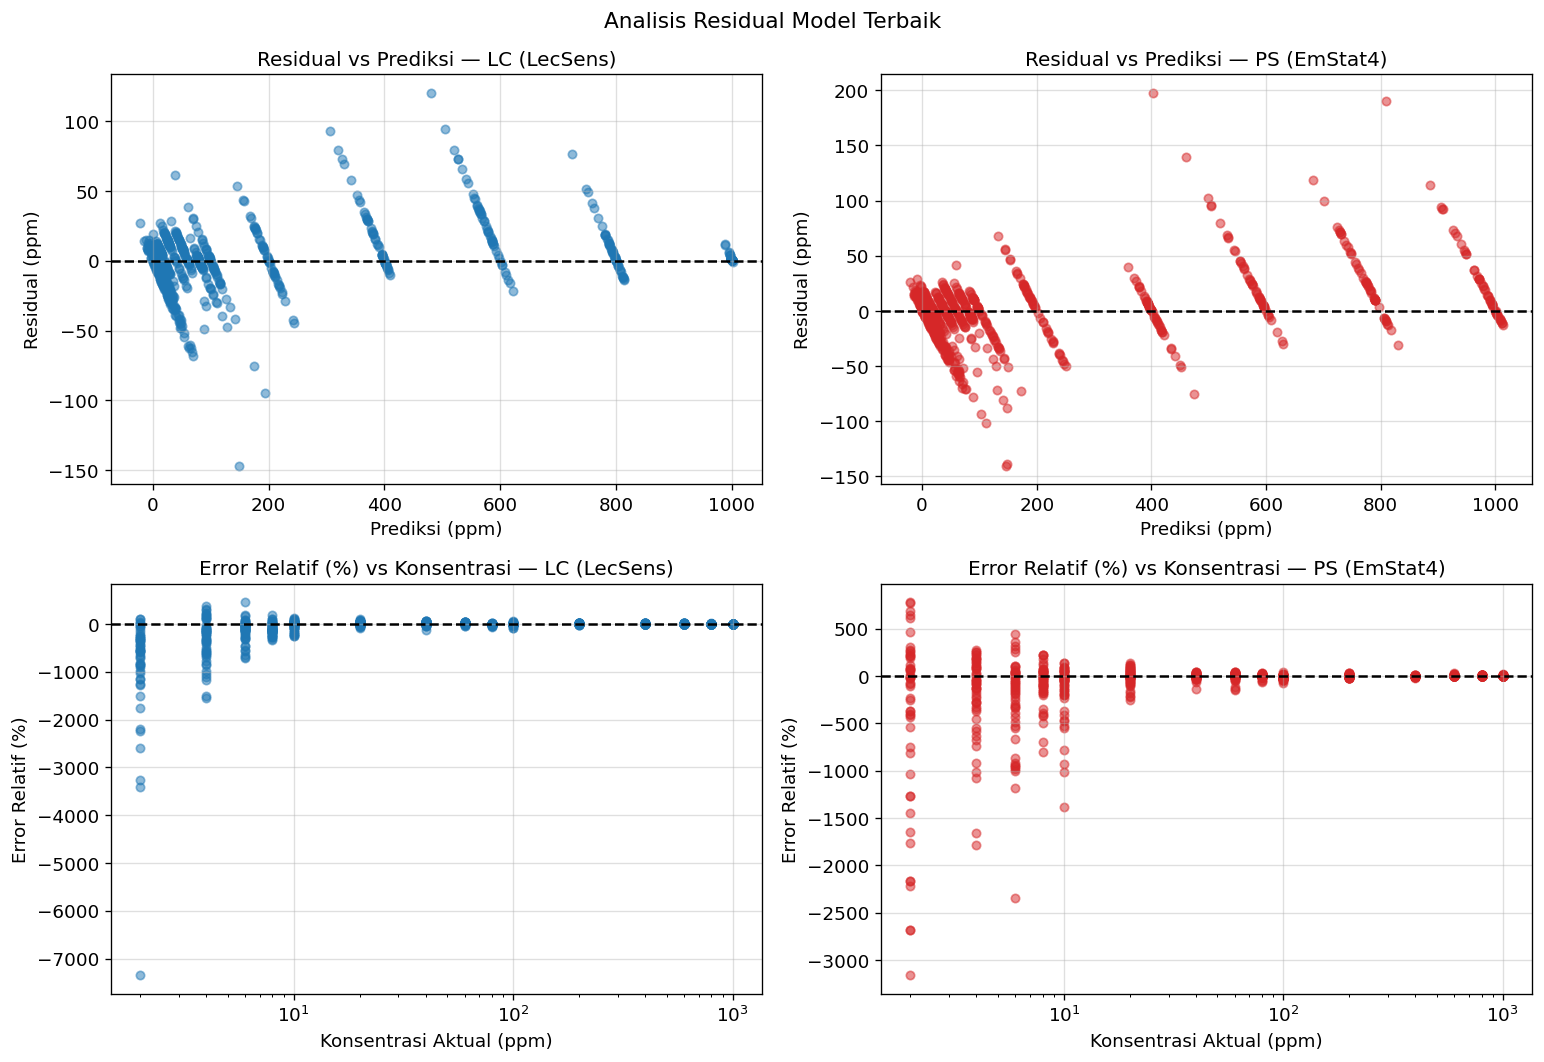

In [36]:
# ── 7.2 Residual Analysis ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for col_idx, (y_true, y_pred, sensor, color) in enumerate([
        (y_lc, y_pred_lc, 'LC (LecSens)', '#1f77b4'),
        (y_ps, y_pred_ps, 'PS (EmStat4)', '#d62728')]):
    
    residuals = y_true - y_pred
    pct_residuals = 100 * residuals / y_true
    
    # Residual vs Predicted
    ax = axes[0, col_idx]
    ax.scatter(y_pred, residuals, c=color, alpha=0.5, s=25)
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.set_xlabel('Prediksi (ppm)')
    ax.set_ylabel('Residual (ppm)')
    ax.set_title(f'Residual vs Prediksi — {sensor}')
    
    # Percentage error vs True
    ax = axes[1, col_idx]
    ax.scatter(y_true, pct_residuals, c=color, alpha=0.5, s=25)
    ax.axhline(0, color='black', lw=1.5, linestyle='--')
    ax.set_xlabel('Konsentrasi Aktual (ppm)')
    ax.set_ylabel('Error Relatif (%)')
    ax.set_title(f'Error Relatif (%) vs Konsentrasi — {sensor}')
    ax.set_xscale('log')

plt.suptitle('Analisis Residual Model Terbaik', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig8_residual_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

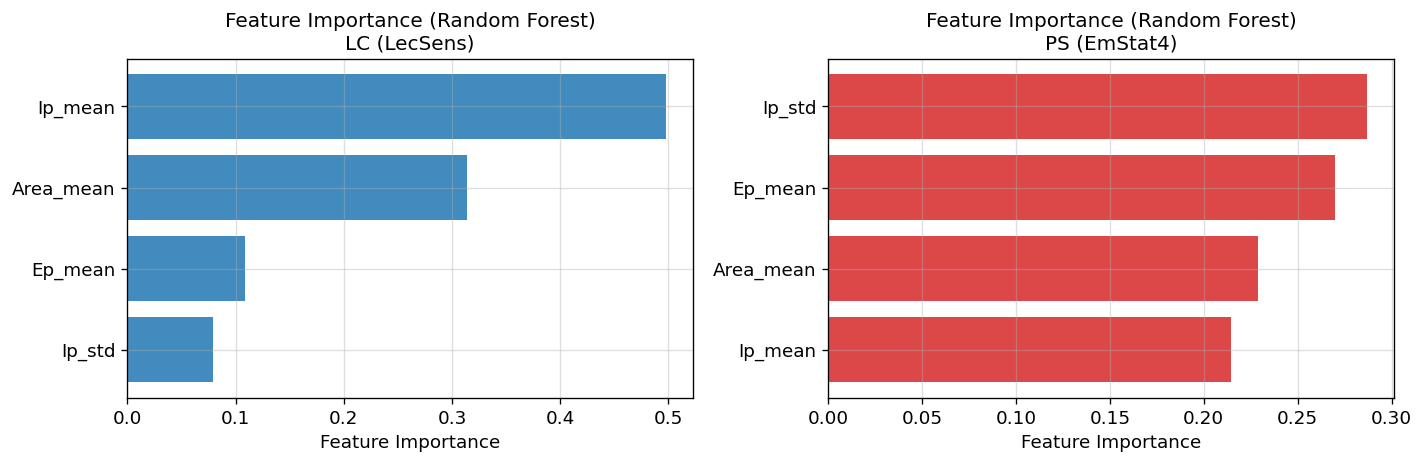

In [37]:
# ── 7.3 Feature Importance (untuk tree-based model) ───────────────────────────
tree_based = ['Random Forest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (X, y, sensor, color) in zip(axes, [
        (X_lc, y_lc, 'LC (LecSens)', '#1f77b4'),
        (X_ps, y_ps, 'PS (EmStat4)', '#d62728')]):
    
    # Gunakan Random Forest untuk feature importance
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(X, y)
    importances = rf.feature_importances_
    
    idx_sort = np.argsort(importances)[::-1]
    sorted_feats = [FEATURE_COLS[i] for i in idx_sort]
    sorted_imp   = importances[idx_sort]
    
    ax.barh(sorted_feats[::-1], sorted_imp[::-1], color=color, alpha=0.85)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Feature Importance (Random Forest)\n{sensor}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig9_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. Perbandingan Kinerja Sensor: LC vs PS

In [38]:
# ── 8.1 Tabel Ringkasan Perbandingan Sensor ───────────────────────────────────

# Ambil metrik model yang SAMA untuk perbandingan fair
# Pilih model dengan R² tertinggi di antara keduanya (atau gunakan semua)
comparison_data = []

for model_name in results_lc['Model']:
    lc_row = results_lc[results_lc['Model'] == model_name].iloc[0]
    ps_row = results_ps[results_ps['Model'] == model_name].iloc[0]
    
    comparison_data.append({
        'Model'         : model_name,
        'LC R²'         : lc_row['R²'],
        'PS R²'         : ps_row['R²'],
        'LC RMSE (ppm)' : lc_row['RMSE (ppm)'],
        'PS RMSE (ppm)' : ps_row['RMSE (ppm)'],
        'LC MAPE (%)'   : lc_row['MAPE (%)'],
        'PS MAPE (%)'   : ps_row['MAPE (%)'],
        'ΔR² (LC−PS)'  : round(lc_row['R²_mean'] - ps_row['R²_mean'], 4)
    })

df_comparison = pd.DataFrame(comparison_data)
df_comparison.to_csv(OUTPUT_DIR / 'comparison_LC_vs_PS.csv', index=False)

print('TABEL PERBANDINGAN SENSOR LC vs PS (5-Fold CV)')
print('=' * 80)
display(df_comparison)

TABEL PERBANDINGAN SENSOR LC vs PS (5-Fold CV)


,Model,LC R²,PS R²,LC RMSE (ppm),PS RMSE (ppm),LC MAPE (%),PS MAPE (%),ΔR² (LC−PS)
0,XGBoost,0.8232 ± 0.0289,0.5794 ± 0.0225,127.85 ± 5.27,199.54 ± 8.47,520.08 ± 60.15,666.33 ± 61.39,0.2438
1,Random Forest,0.8200 ± 0.0402,0.5571 ± 0.0631,128.69 ± 11.65,204.19 ± 12.85,501.46 ± 83.22,593.84 ± 58.95,0.2629
2,LightGBM,0.7958 ± 0.0631,0.5265 ± 0.0478,135.79 ± 15.38,211.40 ± 10.07,653.72 ± 98.85,810.40 ± 138.37,0.2693
3,Polynomial Reg (deg=3),0.4874 ± 0.1294,-103.0639 ± 141.9488,216.46 ± 18.72,2104.55 ± 2379.16,1084.97 ± 194.52,1273.00 ± 291.47,103.5513
4,Linear Regression,0.4309 ± 0.0942,0.0782 ± 0.0332,229.61 ± 13.13,295.71 ± 16.68,1133.98 ± 171.20,1458.26 ± 268.90,0.3527
5,Ridge Regression,0.4232 ± 0.0995,0.0784 ± 0.0331,231.04 ± 12.99,295.67 ± 16.67,1143.38 ± 178.23,1458.90 ± 269.12,0.3448
6,SVR (RBF),0.3635 ± 0.0982,0.2641 ± 0.0632,243.29 ± 19.10,264.34 ± 22.57,248.51 ± 34.13,408.36 ± 86.48,0.0994



=== Parameter Kalibrasi Linear (2–400 ppm) ===
LC: Slope = 0.01568 µA/ppm, Intercept = 2.627 µA, R² = 0.5748
PS: Slope = -0.00372 µA/ppm, Intercept = 12.876 µA, R² = 0.0108


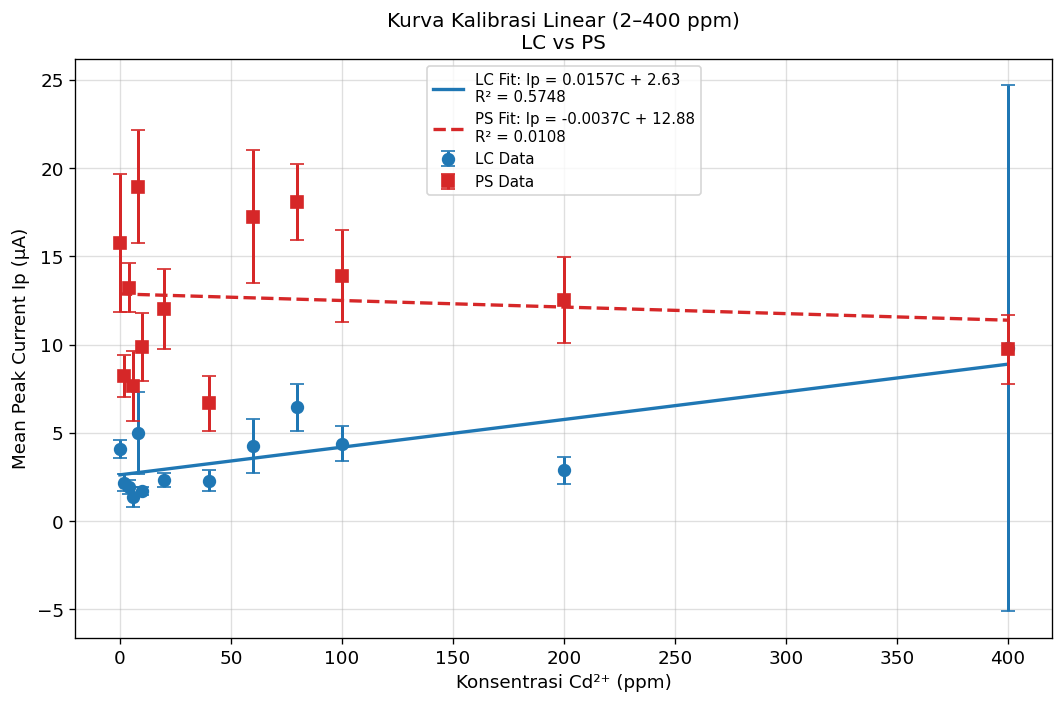

In [39]:
# ── 8.2 Kurva Kalibrasi Linear — Segmen 2–400 ppm ────────────────────────────
# Linearitas biasanya dievaluasi pada range rendah
LINEAR_PPM_MAX = 400

df_lc_lin = df_lc[df_lc['ppm'] <= LINEAR_PPM_MAX]
df_ps_lin = df_ps[df_ps['ppm'] <= LINEAR_PPM_MAX]

lc_stats_lin = df_lc_lin.groupby('ppm')['Ip_mean'].agg(['mean', 'std']).reset_index()
ps_stats_lin = df_ps_lin.groupby('ppm')['Ip_mean'].agg(['mean', 'std']).reset_index()

# Fit linear regression
from numpy.polynomial.polynomial import polyfit
lc_coef = np.polyfit(lc_stats_lin['ppm'], lc_stats_lin['mean'], 1)
ps_coef = np.polyfit(ps_stats_lin['ppm'], ps_stats_lin['mean'], 1)

lc_r2_lin = r2_score(lc_stats_lin['mean'], np.polyval(lc_coef, lc_stats_lin['ppm']))
ps_r2_lin = r2_score(ps_stats_lin['mean'], np.polyval(ps_coef, ps_stats_lin['ppm']))

ppm_line = np.linspace(0, LINEAR_PPM_MAX, 200)

fig, ax = plt.subplots(figsize=(9, 6))

ax.errorbar(lc_stats_lin['ppm'], lc_stats_lin['mean'], yerr=lc_stats_lin['std'],
            fmt='o', color='#1f77b4', capsize=4, ms=7, label='LC Data')
ax.plot(ppm_line, np.polyval(lc_coef, ppm_line), color='#1f77b4', lw=2,
        label=f'LC Fit: Ip = {lc_coef[0]:.4f}C + {lc_coef[1]:.2f}\nR² = {lc_r2_lin:.4f}')

ax.errorbar(ps_stats_lin['ppm'], ps_stats_lin['mean'], yerr=ps_stats_lin['std'],
            fmt='s', color='#d62728', capsize=4, ms=7, label='PS Data')
ax.plot(ppm_line, np.polyval(ps_coef, ppm_line), color='#d62728', lw=2, linestyle='--',
        label=f'PS Fit: Ip = {ps_coef[0]:.4f}C + {ps_coef[1]:.2f}\nR² = {ps_r2_lin:.4f}')

ax.set_xlabel('Konsentrasi Cd²⁺ (ppm)')
ax.set_ylabel('Mean Peak Current Ip (µA)')
ax.set_title(f'Kurva Kalibrasi Linear (2–{LINEAR_PPM_MAX} ppm)\nLC vs PS')
ax.legend(fontsize=9)

print(f'\n=== Parameter Kalibrasi Linear (2–{LINEAR_PPM_MAX} ppm) ===')
print(f"LC: Slope = {lc_coef[0]:.5f} µA/ppm, Intercept = {lc_coef[1]:.3f} µA, R² = {lc_r2_lin:.4f}")
print(f"PS: Slope = {ps_coef[0]:.5f} µA/ppm, Intercept = {ps_coef[1]:.3f} µA, R² = {ps_r2_lin:.4f}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig10_linear_calibration_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

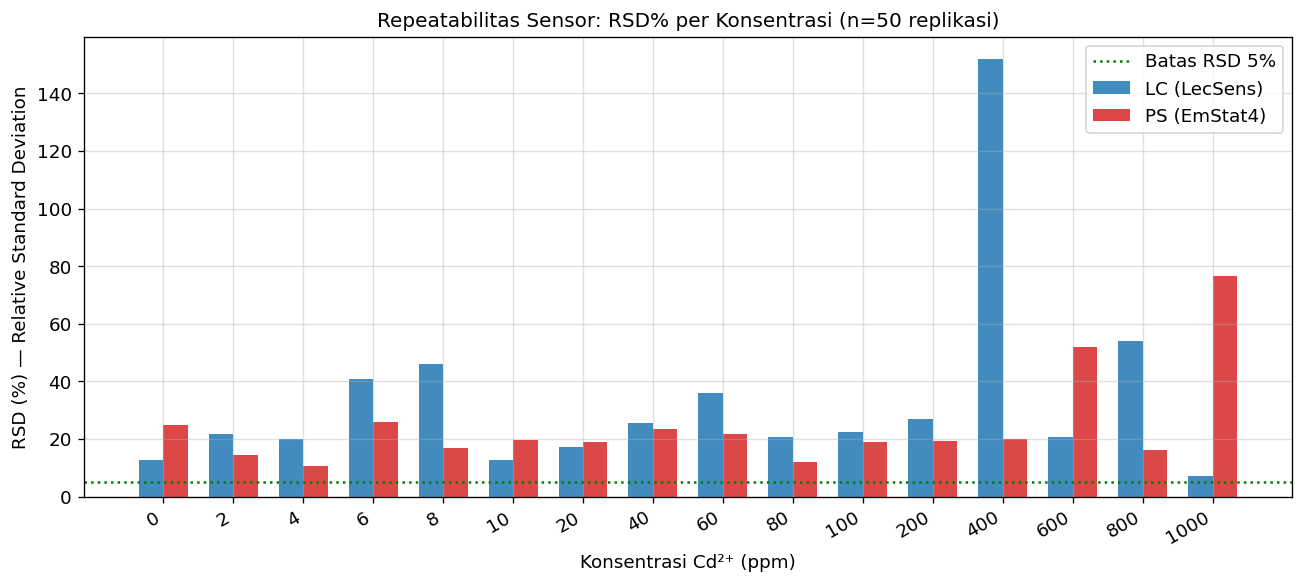


Tabel RSD% per Konsentrasi:


,ppm,RSD_LC,RSD_PS,Δ RSD (LC−PS)
0,0,12.545,24.915,-12.37
1,2,21.796,14.520,7.28
2,4,20.136,10.646,9.49
3,6,40.673,25.837,14.84
4,8,45.979,16.893,29.09
5,10,12.675,19.611,-6.94
6,20,17.123,19.013,-1.89
7,40,25.593,23.433,2.16
8,60,36.098,21.705,14.39
9,80,20.769,11.908,8.86


In [40]:
# ── 8.3 Analisis Repeatabilitas (RSD%) per Konsentrasi ───────────────────────
# RSD = Relative Standard Deviation = (std/mean)*100
lc_rsd = df_lc.groupby('ppm')['Ip_mean'].agg(
    lambda x: 100 * x.std() / x.mean() if x.mean() != 0 else np.nan
).reset_index(name='RSD_LC')

ps_rsd = df_ps.groupby('ppm')['Ip_mean'].agg(
    lambda x: 100 * x.std() / x.mean() if x.mean() != 0 else np.nan
).reset_index(name='RSD_PS')

rsd_merged = lc_rsd.merge(ps_rsd, on='ppm')

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(rsd_merged))
width = 0.35
ax.bar(x - width/2, rsd_merged['RSD_LC'], width, label='LC (LecSens)', color='#1f77b4', alpha=0.85)
ax.bar(x + width/2, rsd_merged['RSD_PS'], width, label='PS (EmStat4)', color='#d62728', alpha=0.85)
ax.axhline(5, color='green', lw=1.5, linestyle=':', label='Batas RSD 5%')
ax.set_xticks(x)
ax.set_xticklabels(rsd_merged['ppm'].astype(str), rotation=30, ha='right')
ax.set_xlabel('Konsentrasi Cd²⁺ (ppm)')
ax.set_ylabel('RSD (%) — Relative Standard Deviation')
ax.set_title('Repeatabilitas Sensor: RSD% per Konsentrasi (n=50 replikasi)')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig11_rsd_repeatability.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nTabel RSD% per Konsentrasi:')
rsd_merged['Δ RSD (LC−PS)'] = (rsd_merged['RSD_LC'] - rsd_merged['RSD_PS']).round(2)
display(rsd_merged.round(3))

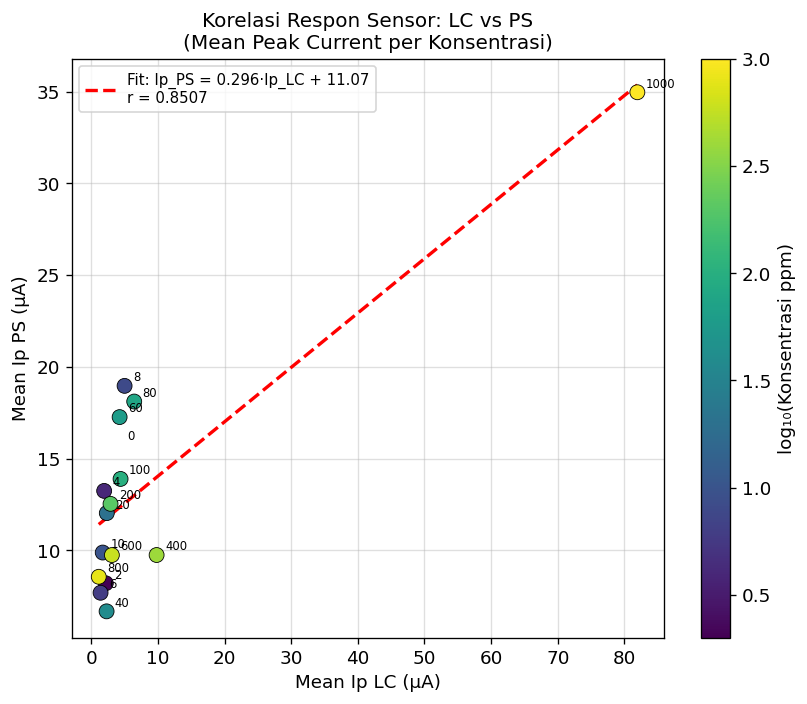


Korelasi Pearson LC vs PS: r = 0.8507


In [41]:
# ── 8.4 Perbandingan Sensor — Scatter Plot (LC Ip vs PS Ip) ───────────────────
lc_mean_ip = df_lc.groupby('ppm')['Ip_mean'].mean()
ps_mean_ip = df_ps.groupby('ppm')['Ip_mean'].mean()

common_ppms = sorted(set(lc_mean_ip.index) & set(ps_mean_ip.index))
lc_vals = lc_mean_ip[common_ppms].values
ps_vals = ps_mean_ip[common_ppms].values

# Korelasi LC vs PS
corr_coef = np.corrcoef(lc_vals, ps_vals)[0, 1]
slope_cross, intercept_cross = np.polyfit(lc_vals, ps_vals, 1)

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(lc_vals, ps_vals, c=np.log10(common_ppms),
                cmap='viridis', s=80, edgecolors='k', lw=0.5, zorder=3)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('log₁₀(Konsentrasi ppm)')

# Annotasi ppm
for p, x_v, y_v in zip(common_ppms, lc_vals, ps_vals):
    ax.annotate(str(p), (x_v, y_v), textcoords='offset points',
                xytext=(5, 3), fontsize=7)

# Regression line
x_line = np.linspace(lc_vals.min(), lc_vals.max(), 100)
ax.plot(x_line, np.polyval([slope_cross, intercept_cross], x_line),
        'r--', lw=2, label=f'Fit: Ip_PS = {slope_cross:.3f}·Ip_LC + {intercept_cross:.2f}\nr = {corr_coef:.4f}')
ax.set_xlabel('Mean Ip LC (µA)')
ax.set_ylabel('Mean Ip PS (µA)')
ax.set_title('Korelasi Respon Sensor: LC vs PS\n(Mean Peak Current per Konsentrasi)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fig12_lc_vs_ps_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\nKorelasi Pearson LC vs PS: r = {corr_coef:.4f}')

---
## 9. Ringkasan Akhir & Kesimpulan

In [42]:
# ── 9.1 Tabel Summary Komparatif ─────────────────────────────────────────────
best_lc_r2   = results_lc.iloc[0]['R²_mean']
best_lc_rmse = results_lc.iloc[0]['RMSE_mean']
best_lc_mae  = results_lc.iloc[0]['MAE_mean']
best_lc_mape = results_lc.iloc[0]['MAPE_mean']

best_ps_r2   = results_ps.iloc[0]['R²_mean']
best_ps_rmse = results_ps.iloc[0]['RMSE_mean']
best_ps_mae  = results_ps.iloc[0]['MAE_mean']
best_ps_mape = results_ps.iloc[0]['MAPE_mean']

lc_rsd_avg  = rsd_merged['RSD_LC'].mean()
ps_rsd_avg  = rsd_merged['RSD_PS'].mean()

summary_data = [
    ['Parameter', 'LC (LecSens)', 'PS (EmStat4)', 'Selisih (LC−PS)'],
    ['Model Terbaik', best_lc_name, best_ps_name, '—'],
    ['Best R² (5-Fold CV)', f'{best_lc_r2:.4f}', f'{best_ps_r2:.4f}', f'{best_lc_r2 - best_ps_r2:+.4f}'],
    ['Best RMSE (ppm)', f'{best_lc_rmse:.2f}', f'{best_ps_rmse:.2f}', f'{best_lc_rmse - best_ps_rmse:+.2f}'],
    ['Best MAE (ppm)', f'{best_lc_mae:.2f}', f'{best_ps_mae:.2f}', f'{best_lc_mae - best_ps_mae:+.2f}'],
    ['Best MAPE (%)', f'{best_lc_mape:.2f}', f'{best_ps_mape:.2f}', f'{best_lc_mape - best_ps_mape:+.2f}'],
    ['Slope Kalibrasi Linear (µA/ppm)', f'{lc_coef[0]:.5f}', f'{ps_coef[0]:.5f}', '—'],
    ['R² Kalibrasi Linear', f'{lc_r2_lin:.4f}', f'{ps_r2_lin:.4f}', f'{lc_r2_lin - ps_r2_lin:+.4f}'],
    ['Mean RSD% (Repeatabilitas)', f'{lc_rsd_avg:.2f}', f'{ps_rsd_avg:.2f}', f'{lc_rsd_avg - ps_rsd_avg:+.2f}'],
]

df_summary = pd.DataFrame(summary_data[1:], columns=summary_data[0])
df_summary.to_csv(OUTPUT_DIR / 'summary_comparison.csv', index=False)

print('=' * 70)
print('RINGKASAN AKHIR: PERBANDINGAN KINERJA SENSOR LC vs PS')
print('Deteksi Cd²⁺ | Range 2–1000 ppm | 5-Fold Cross-Validation')
print('=' * 70)
display(df_summary)

RINGKASAN AKHIR: PERBANDINGAN KINERJA SENSOR LC vs PS
Deteksi Cd²⁺ | Range 2–1000 ppm | 5-Fold Cross-Validation


,Parameter,LC (LecSens),PS (EmStat4),Selisih (LC−PS)
0,Model Terbaik,XGBoost,XGBoost,—
1,Best R² (5-Fold CV),0.8232,0.5794,+0.2438
2,Best RMSE (ppm),127.85,199.54,-71.70
3,Best MAE (ppm),69.99,112.41,-42.41
4,Best MAPE (%),520.08,666.33,-146.25
5,Slope Kalibrasi Linear (µA/ppm),0.01568,-0.00372,—
6,R² Kalibrasi Linear,0.5748,0.0108,+0.5640
7,Mean RSD% (Repeatabilitas),33.54,24.46,+9.08


In [43]:
# ── 9.2 Kesimpulan Otomatis ───────────────────────────────────────────────────
winner_r2    = 'LC (LecSens)' if best_lc_r2   > best_ps_r2   else 'PS (EmStat4)'
winner_rmse  = 'LC (LecSens)' if best_lc_rmse < best_ps_rmse else 'PS (EmStat4)'
winner_mape  = 'LC (LecSens)' if best_lc_mape < best_ps_mape else 'PS (EmStat4)'
winner_rsd   = 'LC (LecSens)' if lc_rsd_avg   < ps_rsd_avg   else 'PS (EmStat4)'
winner_calib = 'LC (LecSens)' if lc_r2_lin    > ps_r2_lin    else 'PS (EmStat4)'

print()
print('━' * 70)
print('KESIMPULAN ANALISIS')
print('━' * 70)
print(f'1. Akurasi Prediksi (R²)          : {winner_r2} lebih unggul')
print(f'   LC R²={best_lc_r2:.4f} vs PS R²={best_ps_r2:.4f}')
print(f'\n2. Akurasi Error (RMSE/MAPE)      : {winner_rmse}/{winner_mape} lebih baik')
print(f'   LC RMSE={best_lc_rmse:.2f} ppm, MAPE={best_lc_mape:.2f}%')
print(f'   PS RMSE={best_ps_rmse:.2f} ppm, MAPE={best_ps_mape:.2f}%')
print(f'\n3. Repeatabilitas (RSD%)          : {winner_rsd} lebih presisi')
print(f'   LC RSD_avg={lc_rsd_avg:.2f}% vs PS RSD_avg={ps_rsd_avg:.2f}%')
print(f'\n4. Linearitas Kalibrasi (2–400 ppm): {winner_calib} lebih linear')
print(f'   LC R²_lin={lc_r2_lin:.4f} vs PS R²_lin={ps_r2_lin:.4f}')
print()
print(f'Files output tersimpan di: {OUTPUT_DIR}')
print('━' * 70)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KESIMPULAN ANALISIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Akurasi Prediksi (R²)          : LC (LecSens) lebih unggul
   LC R²=0.8232 vs PS R²=0.5794

2. Akurasi Error (RMSE/MAPE)      : LC (LecSens)/LC (LecSens) lebih baik
   LC RMSE=127.85 ppm, MAPE=520.08%
   PS RMSE=199.54 ppm, MAPE=666.33%

3. Repeatabilitas (RSD%)          : PS (EmStat4) lebih presisi
   LC RSD_avg=33.54% vs PS RSD_avg=24.46%

4. Linearitas Kalibrasi (2–400 ppm): LC (LecSens) lebih linear
   LC R²_lin=0.5748 vs PS R²_lin=0.0108

Files output tersimpan di: c:\Users\Hikar\Documents\Kuliah\Bahan Belajar Kuliah Semester 4\AI\UTS Kelas AI A\output
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


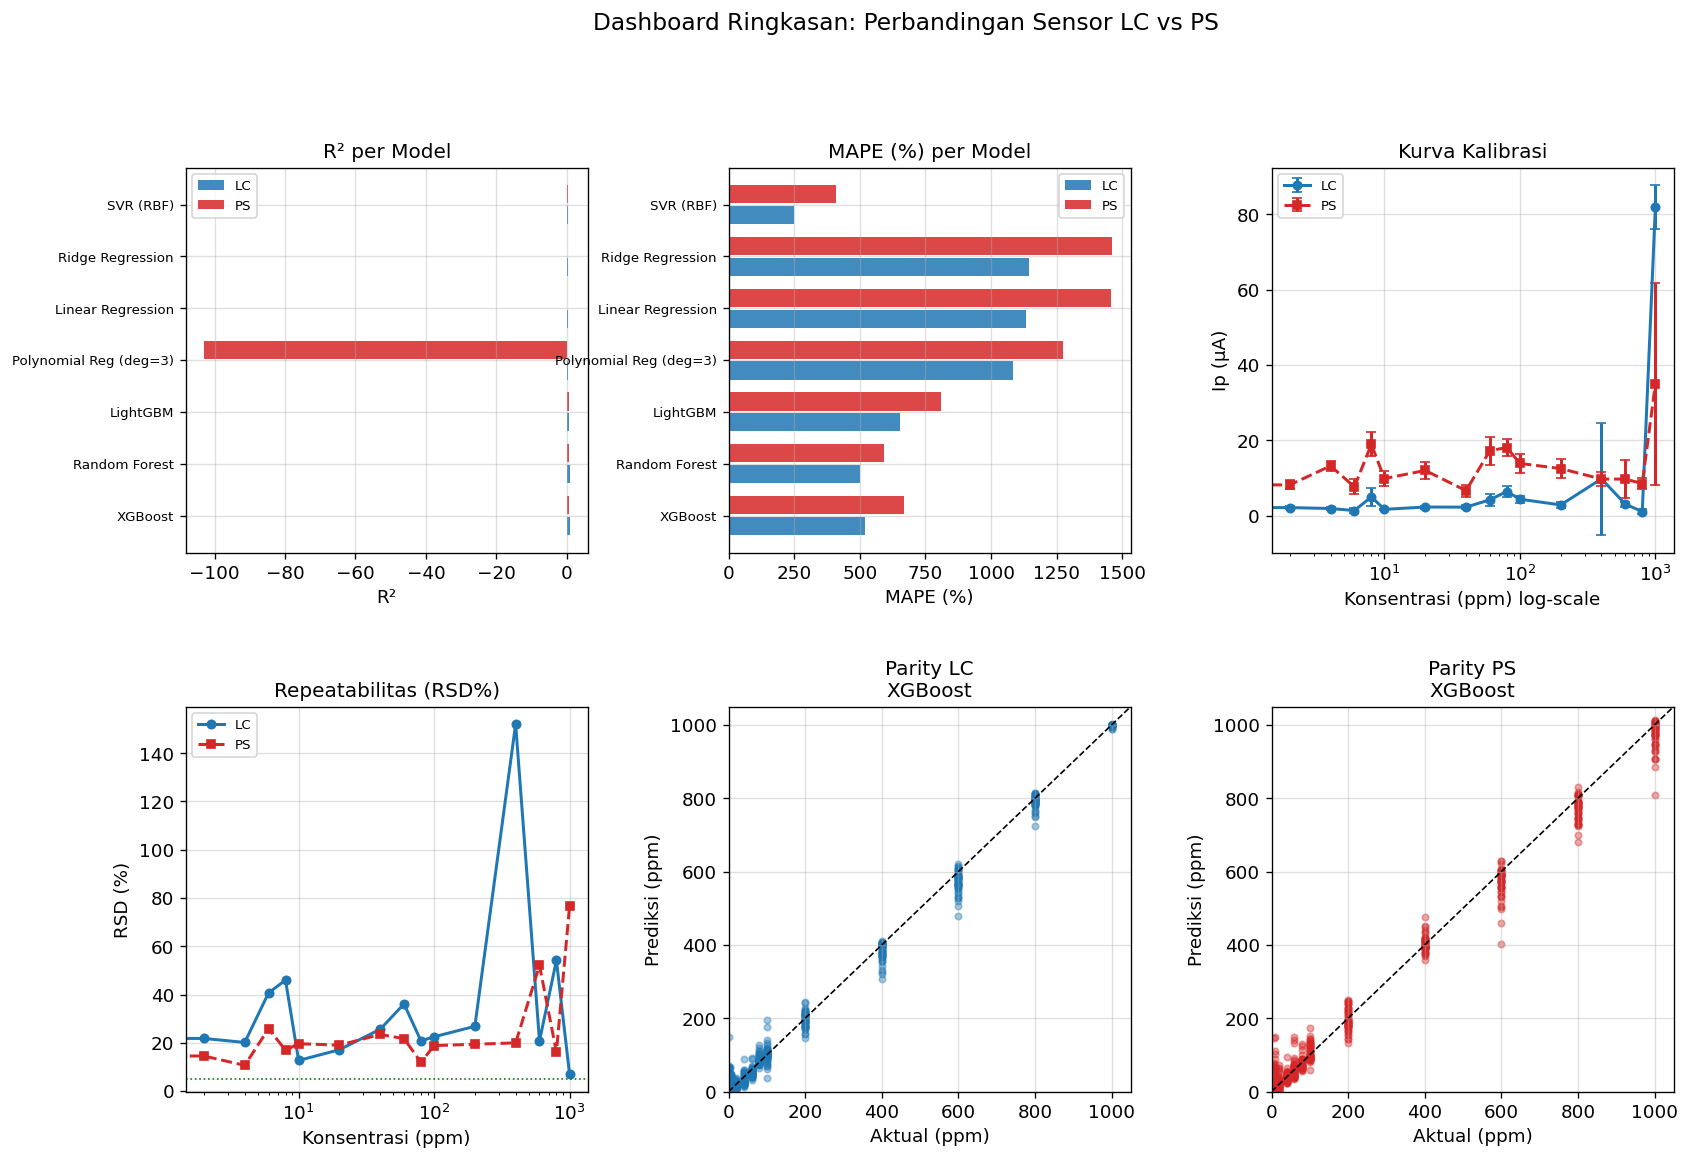

Semua analisis selesai. Output: c:\Users\Hikar\Documents\Kuliah\Bahan Belajar Kuliah Semester 4\AI\UTS Kelas AI A\output


In [44]:
# ── 9.3 Dashboard Ringkasan Visual ───────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1: R² comparison all models
ax1 = fig.add_subplot(gs[0, 0])
model_names_sorted = results_lc['Model'].tolist()
lc_r2s = results_lc.set_index('Model')['R²_mean'][model_names_sorted].values
ps_r2s = results_ps.set_index('Model')['R²_mean'][model_names_sorted].values
x = np.arange(len(model_names_sorted))
ax1.barh(x - 0.2, lc_r2s, 0.35, color='#1f77b4', label='LC', alpha=0.85)
ax1.barh(x + 0.2, ps_r2s, 0.35, color='#d62728', label='PS', alpha=0.85)
ax1.set_yticks(x)
ax1.set_yticklabels(model_names_sorted, fontsize=8)
ax1.set_xlabel('R²')
ax1.set_title('R² per Model')
ax1.legend(fontsize=8)

# Plot 2: MAPE comparison
ax2 = fig.add_subplot(gs[0, 1])
lc_mapes = results_lc.set_index('Model')['MAPE_mean'][model_names_sorted].values
ps_mapes = results_ps.set_index('Model')['MAPE_mean'][model_names_sorted].values
ax2.barh(x - 0.2, lc_mapes, 0.35, color='#1f77b4', label='LC', alpha=0.85)
ax2.barh(x + 0.2, ps_mapes, 0.35, color='#d62728', label='PS', alpha=0.85)
ax2.set_yticks(x)
ax2.set_yticklabels(model_names_sorted, fontsize=8)
ax2.set_xlabel('MAPE (%)')
ax2.set_title('MAPE (%) per Model')
ax2.legend(fontsize=8)

# Plot 3: Calibration curve log scale
ax3 = fig.add_subplot(gs[0, 2])
ax3.errorbar(lc_stats['ppm'], lc_stats['mean'], yerr=lc_stats['std'],
             fmt='o-', color='#1f77b4', capsize=3, ms=5, label='LC')
ax3.errorbar(ps_stats['ppm'], ps_stats['mean'], yerr=ps_stats['std'],
             fmt='s--', color='#d62728', capsize=3, ms=5, label='PS')
ax3.set_xscale('log')
ax3.set_xlabel('Konsentrasi (ppm) log-scale')
ax3.set_ylabel('Ip (µA)')
ax3.set_title('Kurva Kalibrasi')
ax3.legend(fontsize=8)

# Plot 4: RSD comparison
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(rsd_merged['ppm'], rsd_merged['RSD_LC'], 'o-', color='#1f77b4', ms=5, label='LC')
ax4.plot(rsd_merged['ppm'], rsd_merged['RSD_PS'], 's--', color='#d62728', ms=5, label='PS')
ax4.axhline(5, color='green', lw=1, linestyle=':')
ax4.set_xscale('log')
ax4.set_xlabel('Konsentrasi (ppm)')
ax4.set_ylabel('RSD (%)')
ax4.set_title('Repeatabilitas (RSD%)')
ax4.legend(fontsize=8)

# Plot 5: Parity plot terbaik LC
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(y_lc, y_pred_lc, c='#1f77b4', alpha=0.4, s=15)
lim5 = [0, y_lc.max() * 1.05]
ax5.plot(lim5, lim5, 'k--', lw=1)
ax5.set_xlim(lim5); ax5.set_ylim(lim5)
ax5.set_xlabel('Aktual (ppm)'); ax5.set_ylabel('Prediksi (ppm)')
ax5.set_title(f'Parity LC\n{best_lc_name[:20]}...' if len(best_lc_name)>20 else f'Parity LC\n{best_lc_name}')

# Plot 6: Parity plot terbaik PS
ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(y_ps, y_pred_ps, c='#d62728', alpha=0.4, s=15)
lim6 = [0, y_ps.max() * 1.05]
ax6.plot(lim6, lim6, 'k--', lw=1)
ax6.set_xlim(lim6); ax6.set_ylim(lim6)
ax6.set_xlabel('Aktual (ppm)'); ax6.set_ylabel('Prediksi (ppm)')
ax6.set_title(f'Parity PS\n{best_ps_name[:20]}...' if len(best_ps_name)>20 else f'Parity PS\n{best_ps_name}')

plt.suptitle('Dashboard Ringkasan: Perbandingan Sensor LC vs PS', fontsize=14, y=1.01)
plt.savefig(OUTPUT_DIR / 'fig13_dashboard_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print('Semua analisis selesai. Output:', OUTPUT_DIR)